# Phase 2: PBMC3k exploratory analysis and clustering

This notebook loads the QC-filtered, normalized PBMC3k object produced by `02_qc_preprocessing.ipynb` and performs PCA, nearest-neighbor graph construction, UMAP, K-means model selection, t-SNE, cluster-level QC comparisons, marker-gene discovery, and an investigation of why particular RNA markers dominate clusters.

**Important distinction:** K-means assigns cluster labels. UMAP and t-SNE are nonlinear two-dimensional embeddings used to visualize those labels; t-SNE is not itself a clustering algorithm.

## Analysis plan

1. Use the 2,000 genes selected during preprocessing and scale them for PCA.
2. Construct a nearest-neighbor graph from the leading principal components.
3. Evaluate K=2 through K=10 using inertia, silhouette, stability across random initializations, cluster-size balance, and association with technical QC metrics.
4. Inspect every candidate on UMAP and select the strongest overall solution with a documented multi-evidence score; elbow and silhouette are supporting evidence, not the sole decision rule.
5. Display the final clusters on UMAP and t-SNE embeddings.
6. Compare cluster sizes and QC distributions.
7. Test every gene retained in `adata.raw` for cluster markers.
8. distinguish biological markers from technical or ubiquitous genes using expression prevalence, fold change, QC relationships, and mitochondrial/ribosomal annotation.

In [3]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from IPython.display import display
from scipy import sparse
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, silhouette_score

RANDOM_STATE = 42
N_PCS = 30
N_NEIGHBORS = 15
K_VALUES = range(2, 11)
STABILITY_SEEDS = (7, 21, 42, 84, 168)
MIN_ACCEPTABLE_CLUSTER_CELLS = 30
MIN_ACCEPTABLE_CLUSTER_PERCENT = 1.0
SILHOUETTE_SAMPLE_SIZE = 2_000
N_MARKERS = 10

ad.settings.allow_write_nullable_strings = True
sc.settings.verbosity = 2
sc.set_figure_params(dpi=110, facecolor="white", frameon=False)
sns.set_theme(style="whitegrid", context="notebook")

In [4]:
# Locate the PBMC3k project whether the kernel starts at the repository root,
# PBMC3k/, or PBMC3k/notebooks/.
cwd = Path.cwd().resolve()
candidates = []
for base in (cwd, *cwd.parents):
    candidates.extend(
        (
            base,
            base / "PBMC3k",
            base / "26-the-backpropagators-analysis" / "PBMC3k",
        )
    )

PROJECT = next(
    (path for path in candidates if (path / "data" / "processed" / "pbmc3k_phase1_qc_top2000sd.h5ad").is_file()),
    None,
)
if PROJECT is None:
    raise FileNotFoundError(
        "Run 02_qc_preprocessing.ipynb first; expected "
        "PBMC3k/data/processed/pbmc3k_phase1_qc_top2000sd.h5ad"
    )

INPUT = PROJECT / "data" / "processed" / "pbmc3k_phase1_qc_top2000sd.h5ad"
OUTPUT = PROJECT / "data" / "processed" / "pbmc3k_phase2_clustered.h5ad"
FIGURES = PROJECT / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

adata = sc.read_h5ad(INPUT)
print(adata)
print("Input:", INPUT)
print("Full normalized expression available for marker testing:", adata.raw is not None)
display(adata.obs[[c for c in ["total_counts", "n_genes_by_counts", "pct_counts_mt"] if c in adata.obs]].describe().T)

AnnData object with n_obs × n_vars = 2638 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pass_min_genes', 'pass_max_genes', 'pass_mt', 'pass_qc'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'expression_mean', 'expression_std', 'std_rank', 'selected_by_std'
    uns: 'log1p'
    layers: 'counts'
Input: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC3k/data/processed/pbmc3k_phase1_qc_top2000sd.h5ad
Full normalized expression available for marker testing: True


,count,mean,std,min,25%,50%,75%,max
total_counts,2638.0,2371.025391,990.121094,556.0,1779.250000,2213.000000,2766.000000,8875.000000
n_genes_by_counts,2638.0,848.606899,262.727587,212.0,699.000000,819.000000,954.000000,2413.000000
pct_counts_mt,2638.0,2.116608,0.843120,0.0,1.520267,2.010702,2.591085,4.995375


## PCA

PCA summarizes correlated gene-expression variation with orthogonal components. Scaling prevents a small number of high-variance genes from overwhelming the decomposition. Values are capped at 10 standard deviations to reduce the influence of extreme observations.

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:01)


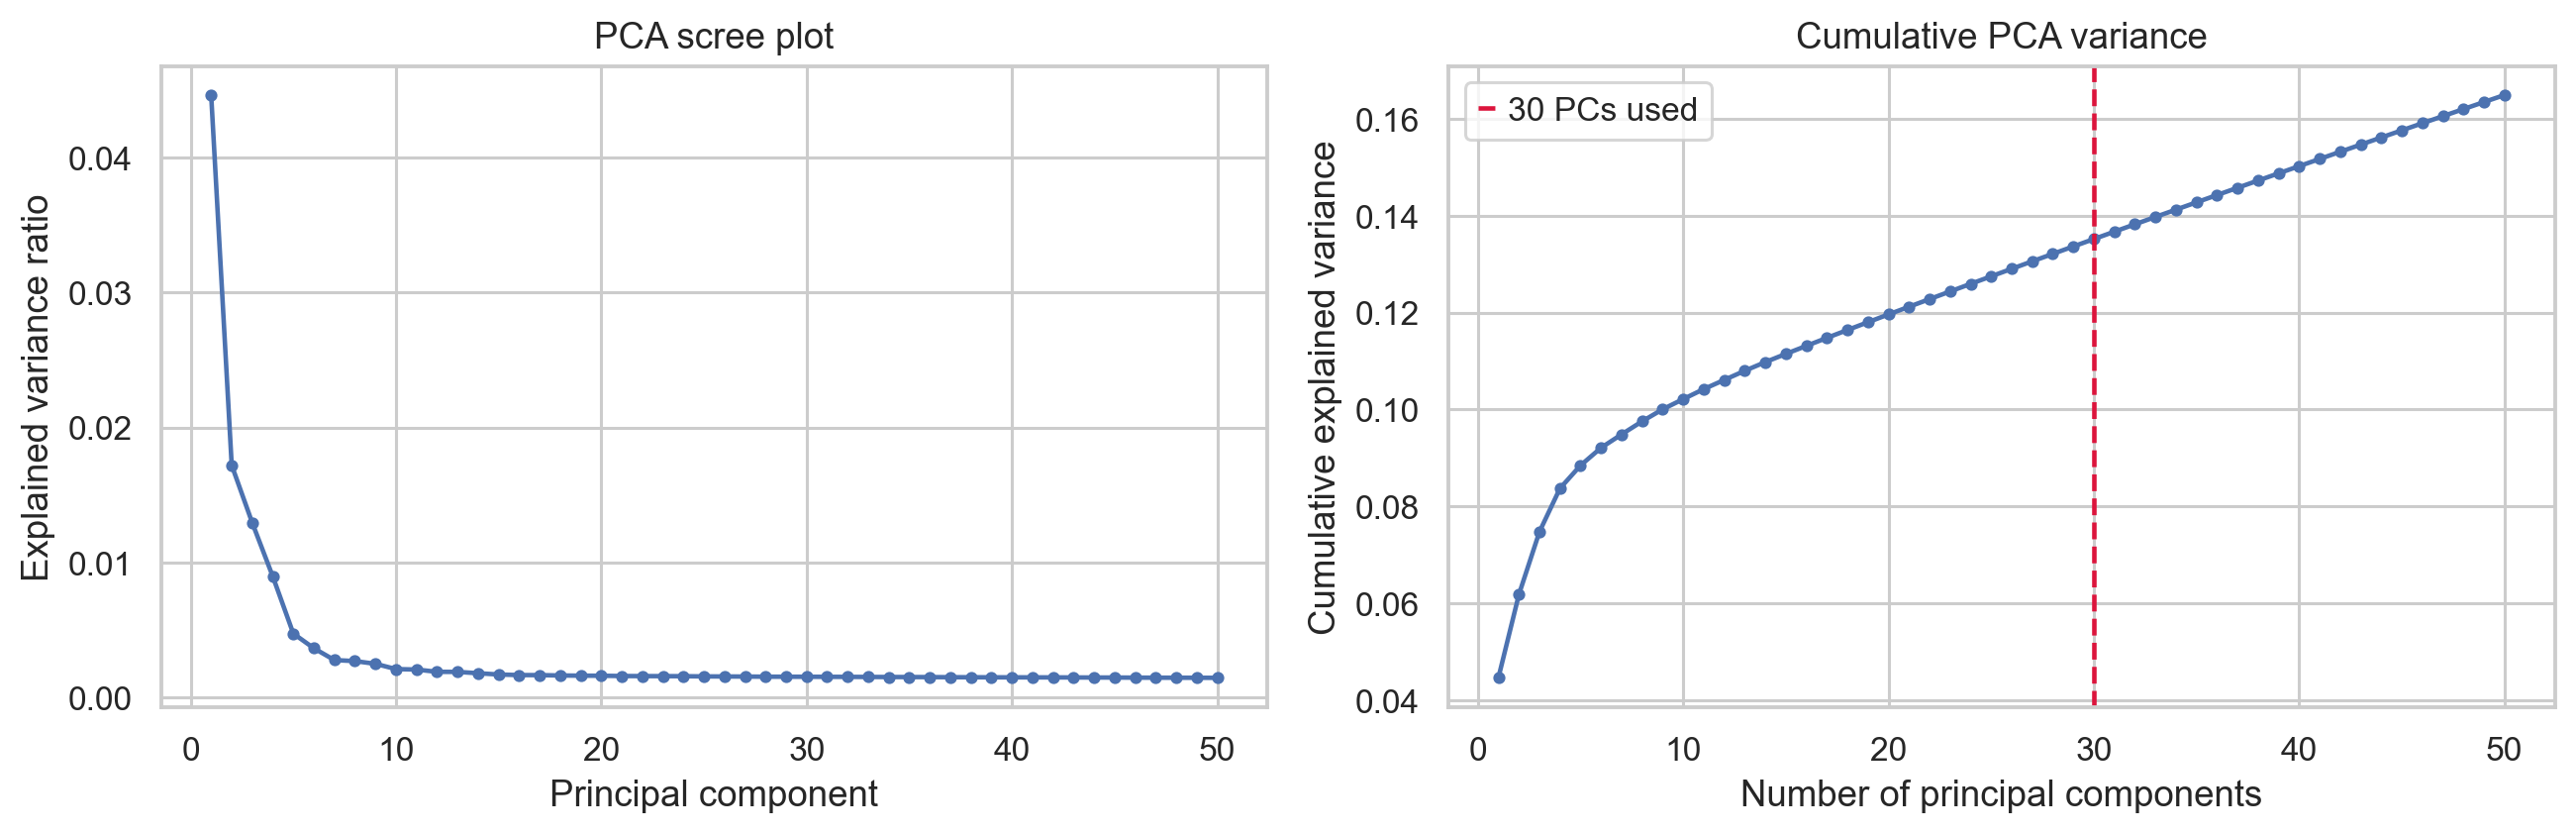

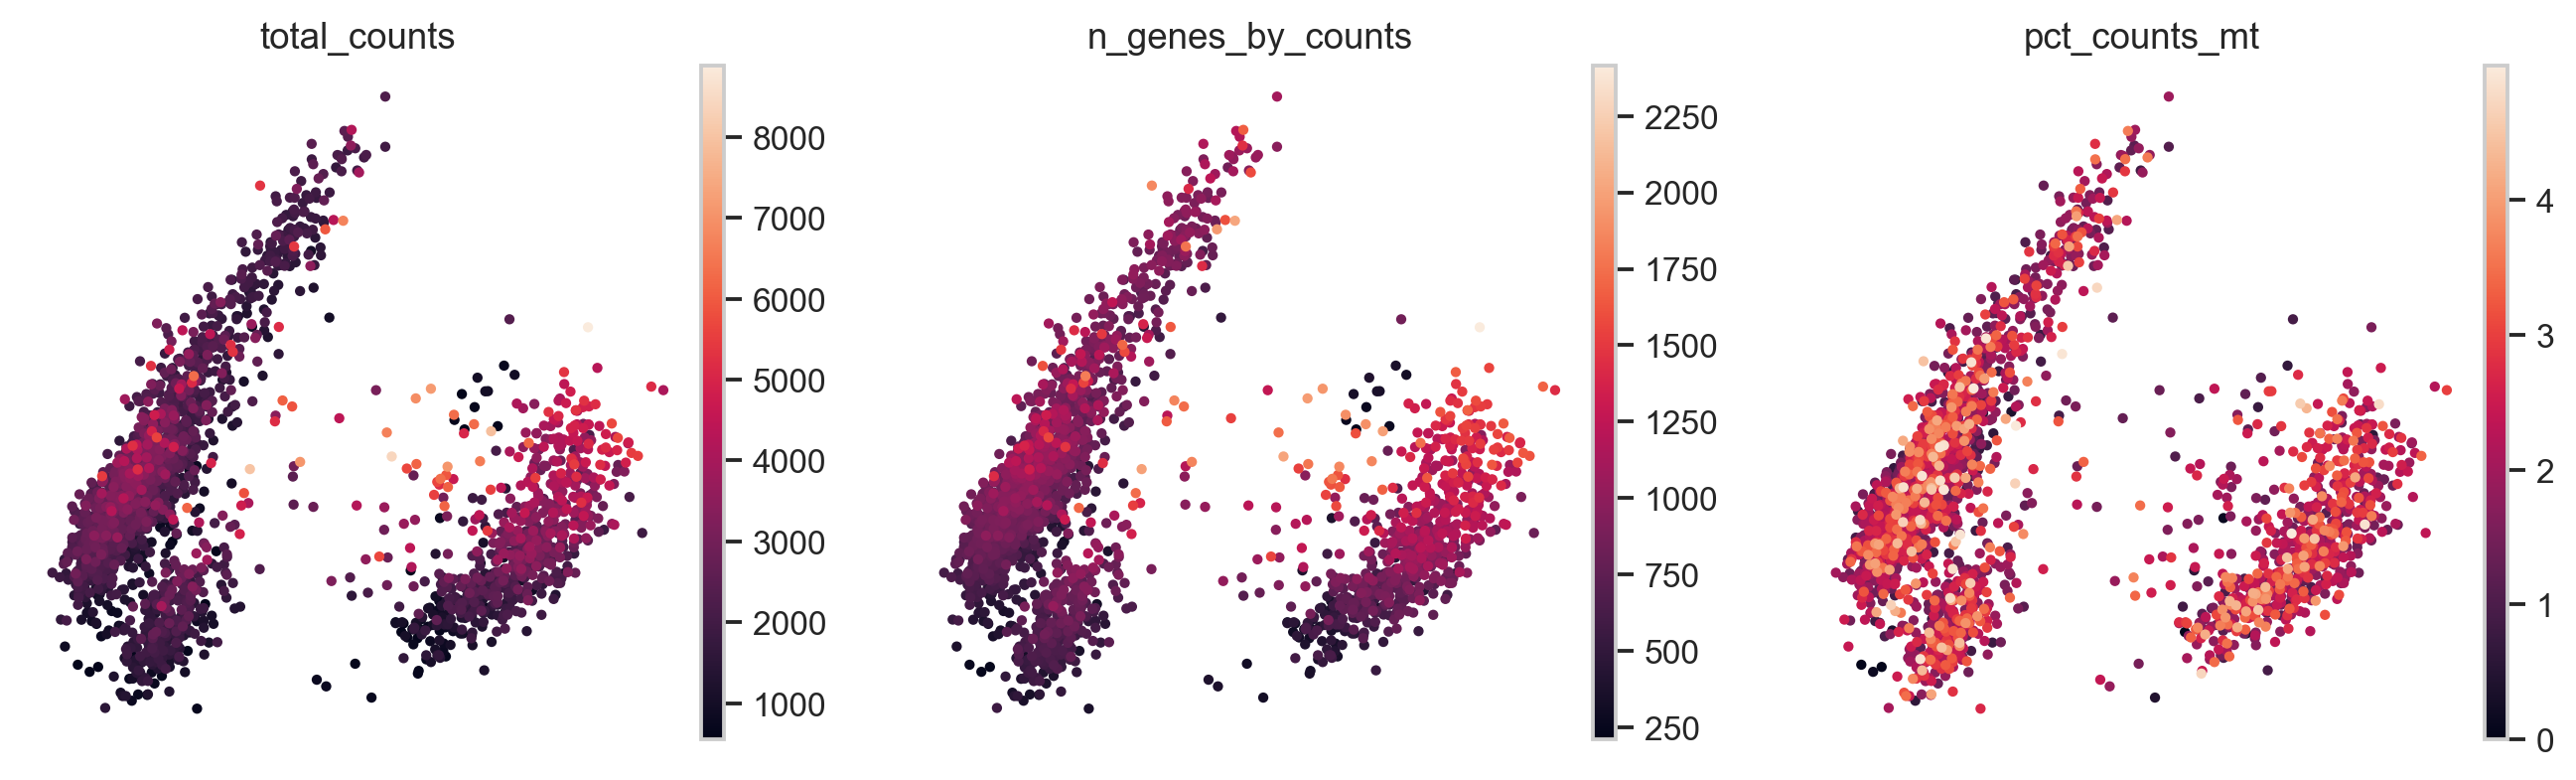

In [5]:
# Preserve normalized log-expression before scaling the selected-gene matrix.
adata.layers["log_normalized"] = adata.X.copy()
sc.pp.scale(adata, max_value=10)
n_pcs_available = min(50, adata.n_obs - 1, adata.n_vars - 1)
sc.tl.pca(adata, n_comps=n_pcs_available, svd_solver="arpack", random_state=RANDOM_STATE)

variance = adata.uns["pca"]["variance_ratio"]
cumulative_variance = np.cumsum(variance)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, len(variance) + 1), variance, marker="o", markersize=3)
axes[0].set(xlabel="Principal component", ylabel="Explained variance ratio", title="PCA scree plot")
axes[1].plot(np.arange(1, len(variance) + 1), cumulative_variance, marker="o", markersize=3)
axes[1].axvline(min(N_PCS, len(variance)), color="crimson", linestyle="--", label=f"{min(N_PCS, len(variance))} PCs used")
axes[1].set(xlabel="Number of principal components", ylabel="Cumulative explained variance", title="Cumulative PCA variance")
axes[1].legend()
plt.tight_layout()
plt.show()

sc.pl.pca(adata, color=[c for c in ["total_counts", "n_genes_by_counts", "pct_counts_mt"] if c in adata.obs], ncols=3)

## Nearest-neighbor graph and UMAP

The graph connects each cell to nearby cells in PCA space. UMAP then represents this graph in two dimensions. Distances and apparent gaps in UMAP are useful exploratory signals, but they should not be interpreted as exact biological distances.

computing neighbors
    using 'X_pca' with n_pcs = 30


/Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC3k/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished (0:00:30)
computing UMAP
    finished (0:00:05)


,nearest-neighbor graph
cells,2638.000000
PCs used,30.000000
requested neighbors per cell,15.000000
nonzero undirected graph entries,58672.000000
mean nonzero connections per cell,22.241092


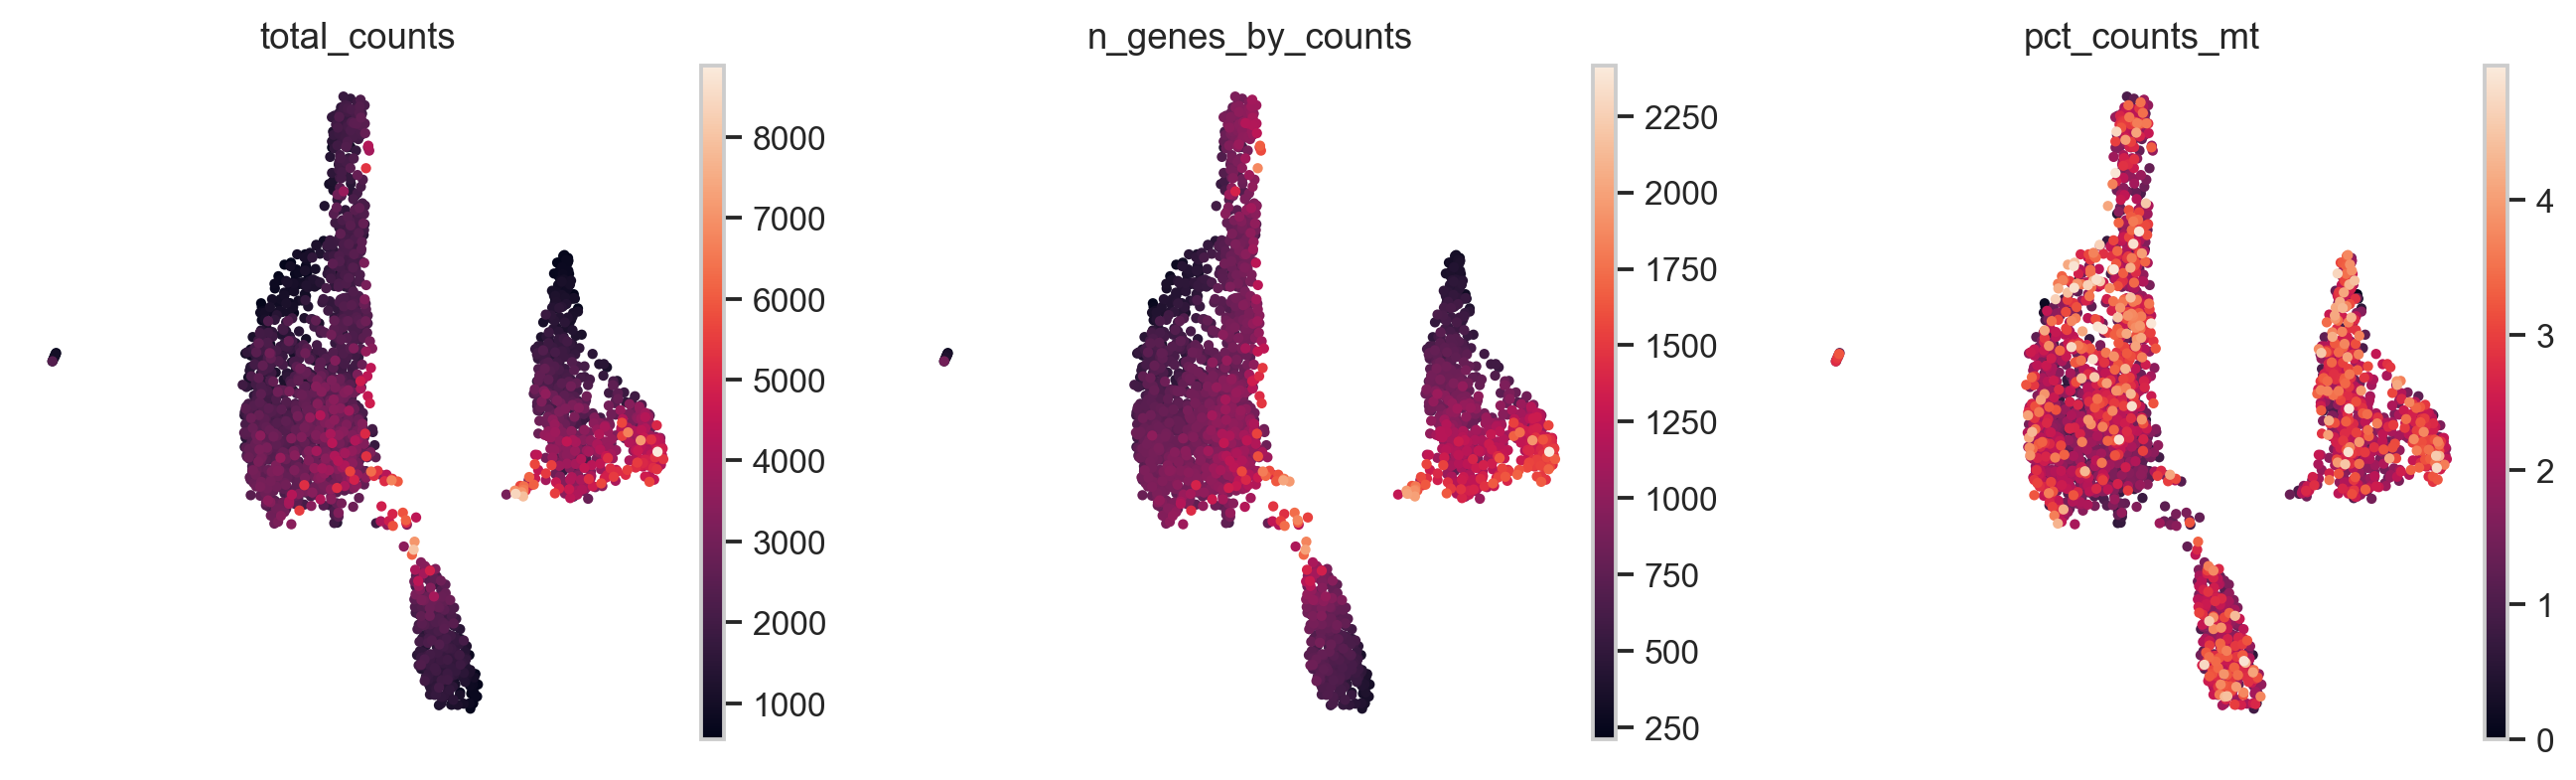

In [6]:
pcs_used = min(N_PCS, adata.obsm["X_pca"].shape[1])
sc.pp.neighbors(adata, n_neighbors=N_NEIGHBORS, n_pcs=pcs_used, method="umap", random_state=RANDOM_STATE)
sc.tl.umap(adata, random_state=RANDOM_STATE)

connectivities = adata.obsp["connectivities"]
graph_summary = pd.Series({
    "cells": adata.n_obs,
    "PCs used": pcs_used,
    "requested neighbors per cell": N_NEIGHBORS,
    "nonzero undirected graph entries": int(connectivities.nnz),
    "mean nonzero connections per cell": float(connectivities.getnnz(axis=1).mean()),
}, name="nearest-neighbor graph")
display(graph_summary.to_frame())
sc.pl.umap(adata, color=[c for c in ["total_counts", "n_genes_by_counts", "pct_counts_mt"] if c in adata.obs], ncols=3)

## Determine the best K from 2 through 10

- **Elbow:** inertia always decreases as K increases. The geometric elbow is the point with the largest perpendicular distance from the straight line joining the first and last inertia values.
- **Silhouette:** compares within-cluster cohesion with separation from the nearest other cluster; larger values are better.
- **Stability:** mean adjusted Rand index (ARI) measures whether repeated K-means initializations recover similar partitions.
- **Cluster viability:** the smallest cluster must contain at least 30 cells and 1% of the dataset; tiny partitions are penalized as potentially brittle over-clustering.
- **QC independence:** eta-squared measures how much cluster labels separate total counts, detected genes, or mitochondrial percentage. Lower values are preferred because a technically driven solution is less biologically useful.
- **Visual structure:** all nine candidate labelings are shown on the same UMAP for an explicit plausibility check.

The final K maximizes a documented composite of silhouette (35%), stability (30%), viable cluster size (20%), and QC independence (15%), after excluding candidates with implausibly small clusters. The elbow is reported as supporting evidence but does not control the answer. This makes the selection reproducible while incorporating robustness and biological plausibility beyond two curve-based diagnostics.

,inertia,silhouette,stability_ari,smallest_cluster_cells,smallest_cluster_percent,max_qc_eta_squared,elbow_distance,viable_size,silhouette_rank,stability_rank,size_rank,qc_independence_rank,overall_score
k,,,,,,,,,,,,,
2,"498,579",0.346,1.000,685,26.0%,0.082,0.000,True,1.000000,0.944444,1.000000,1.000000,0.983
3,"433,948",0.320,0.999,306,11.6%,0.105,0.169,True,0.888889,0.666667,0.888889,0.888889,0.822
4,"381,645",0.268,1.000,292,11.1%,0.123,0.282,True,0.777778,0.777778,0.777778,0.777778,0.778
5,"355,067",0.233,1.000,281,10.7%,0.342,0.278,True,0.666667,0.944444,0.666667,0.555556,0.733
6,"335,889",0.204,0.806,158,6.0%,0.342,0.240,True,0.555556,0.111111,0.555556,0.666667,0.439
7,"313,014",0.162,0.922,11,0.4%,0.420,0.219,False,0.444444,0.222222,0.277778,0.444444,0.344
8,"298,701",0.156,0.989,11,0.4%,0.445,0.159,False,0.333333,0.444444,0.277778,0.333333,0.356
9,"286,128",0.148,0.989,11,0.4%,0.477,0.091,False,0.222222,0.555556,0.277778,0.222222,0.333
10,"278,681",0.143,0.938,11,0.4%,0.524,0.000,False,0.111111,0.333333,0.277778,0.111111,0.211


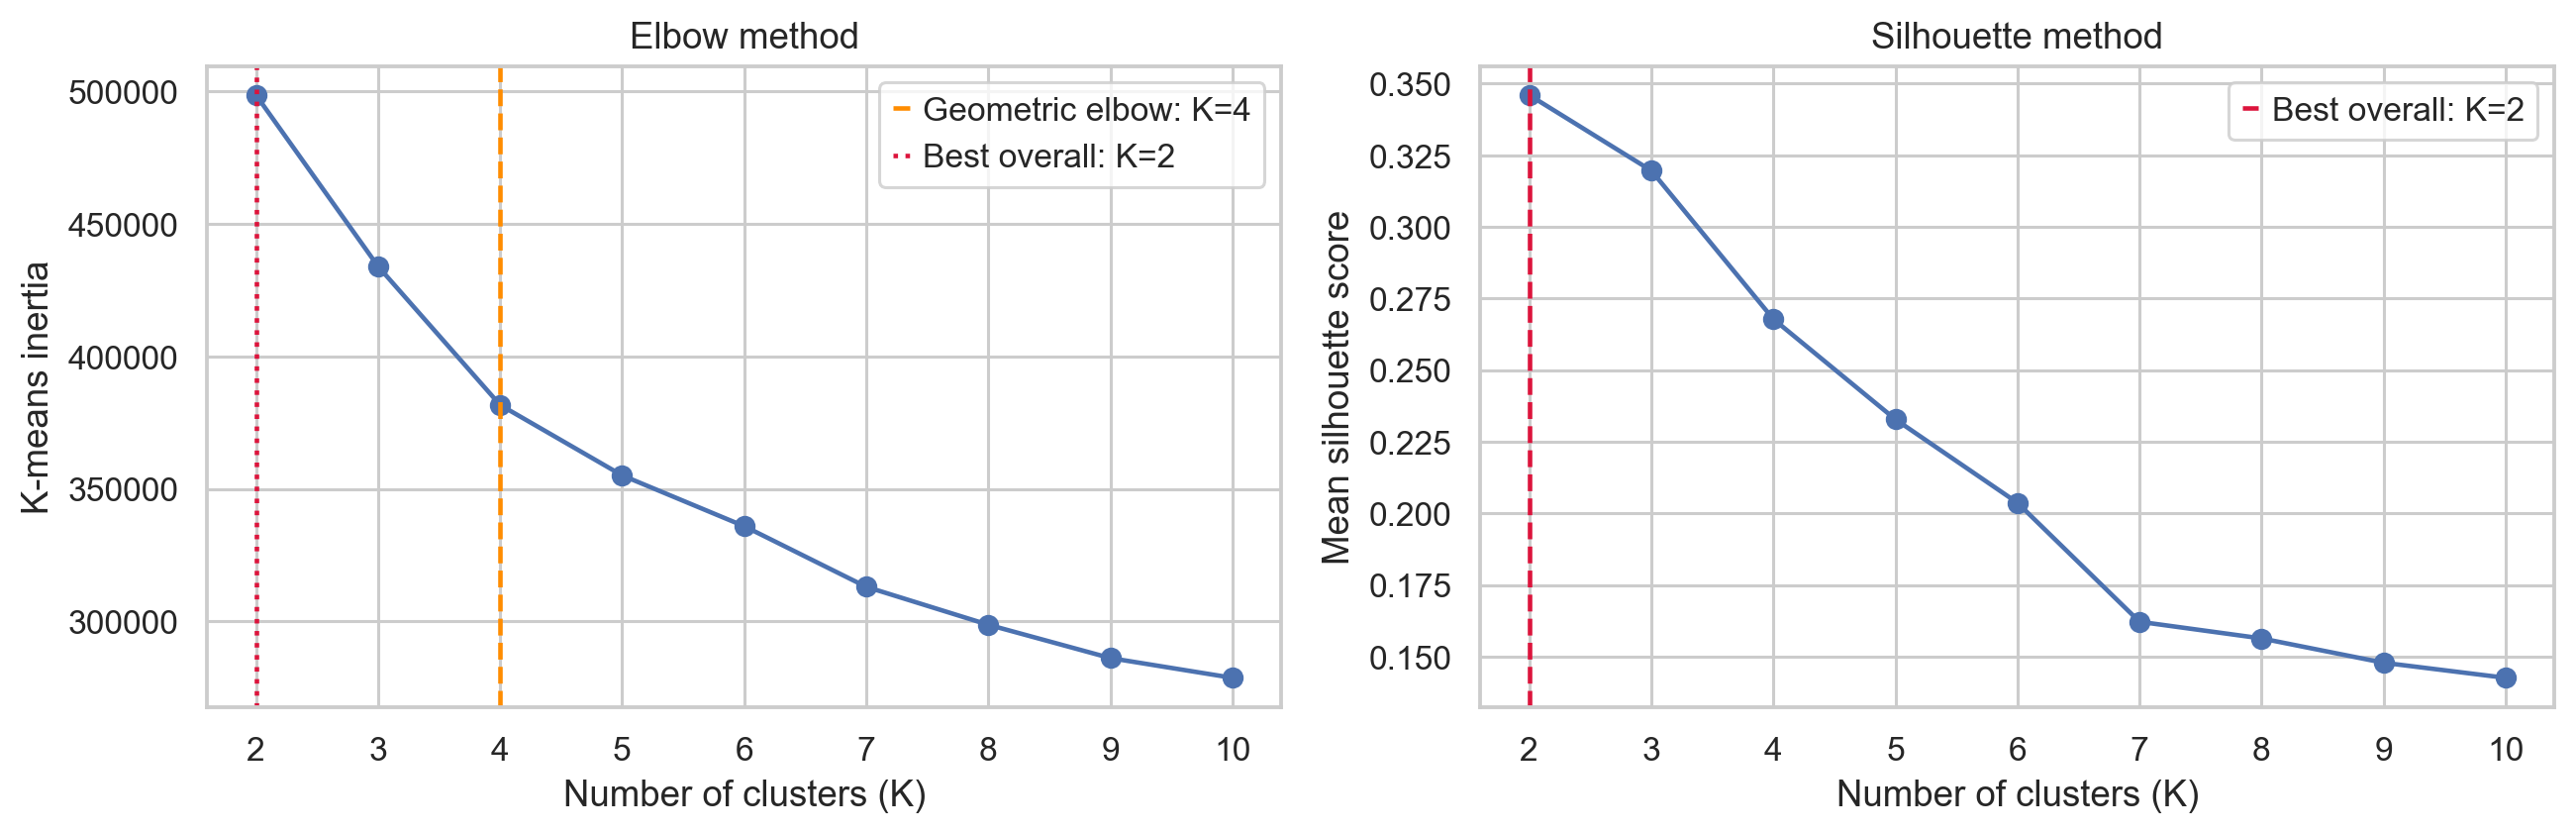

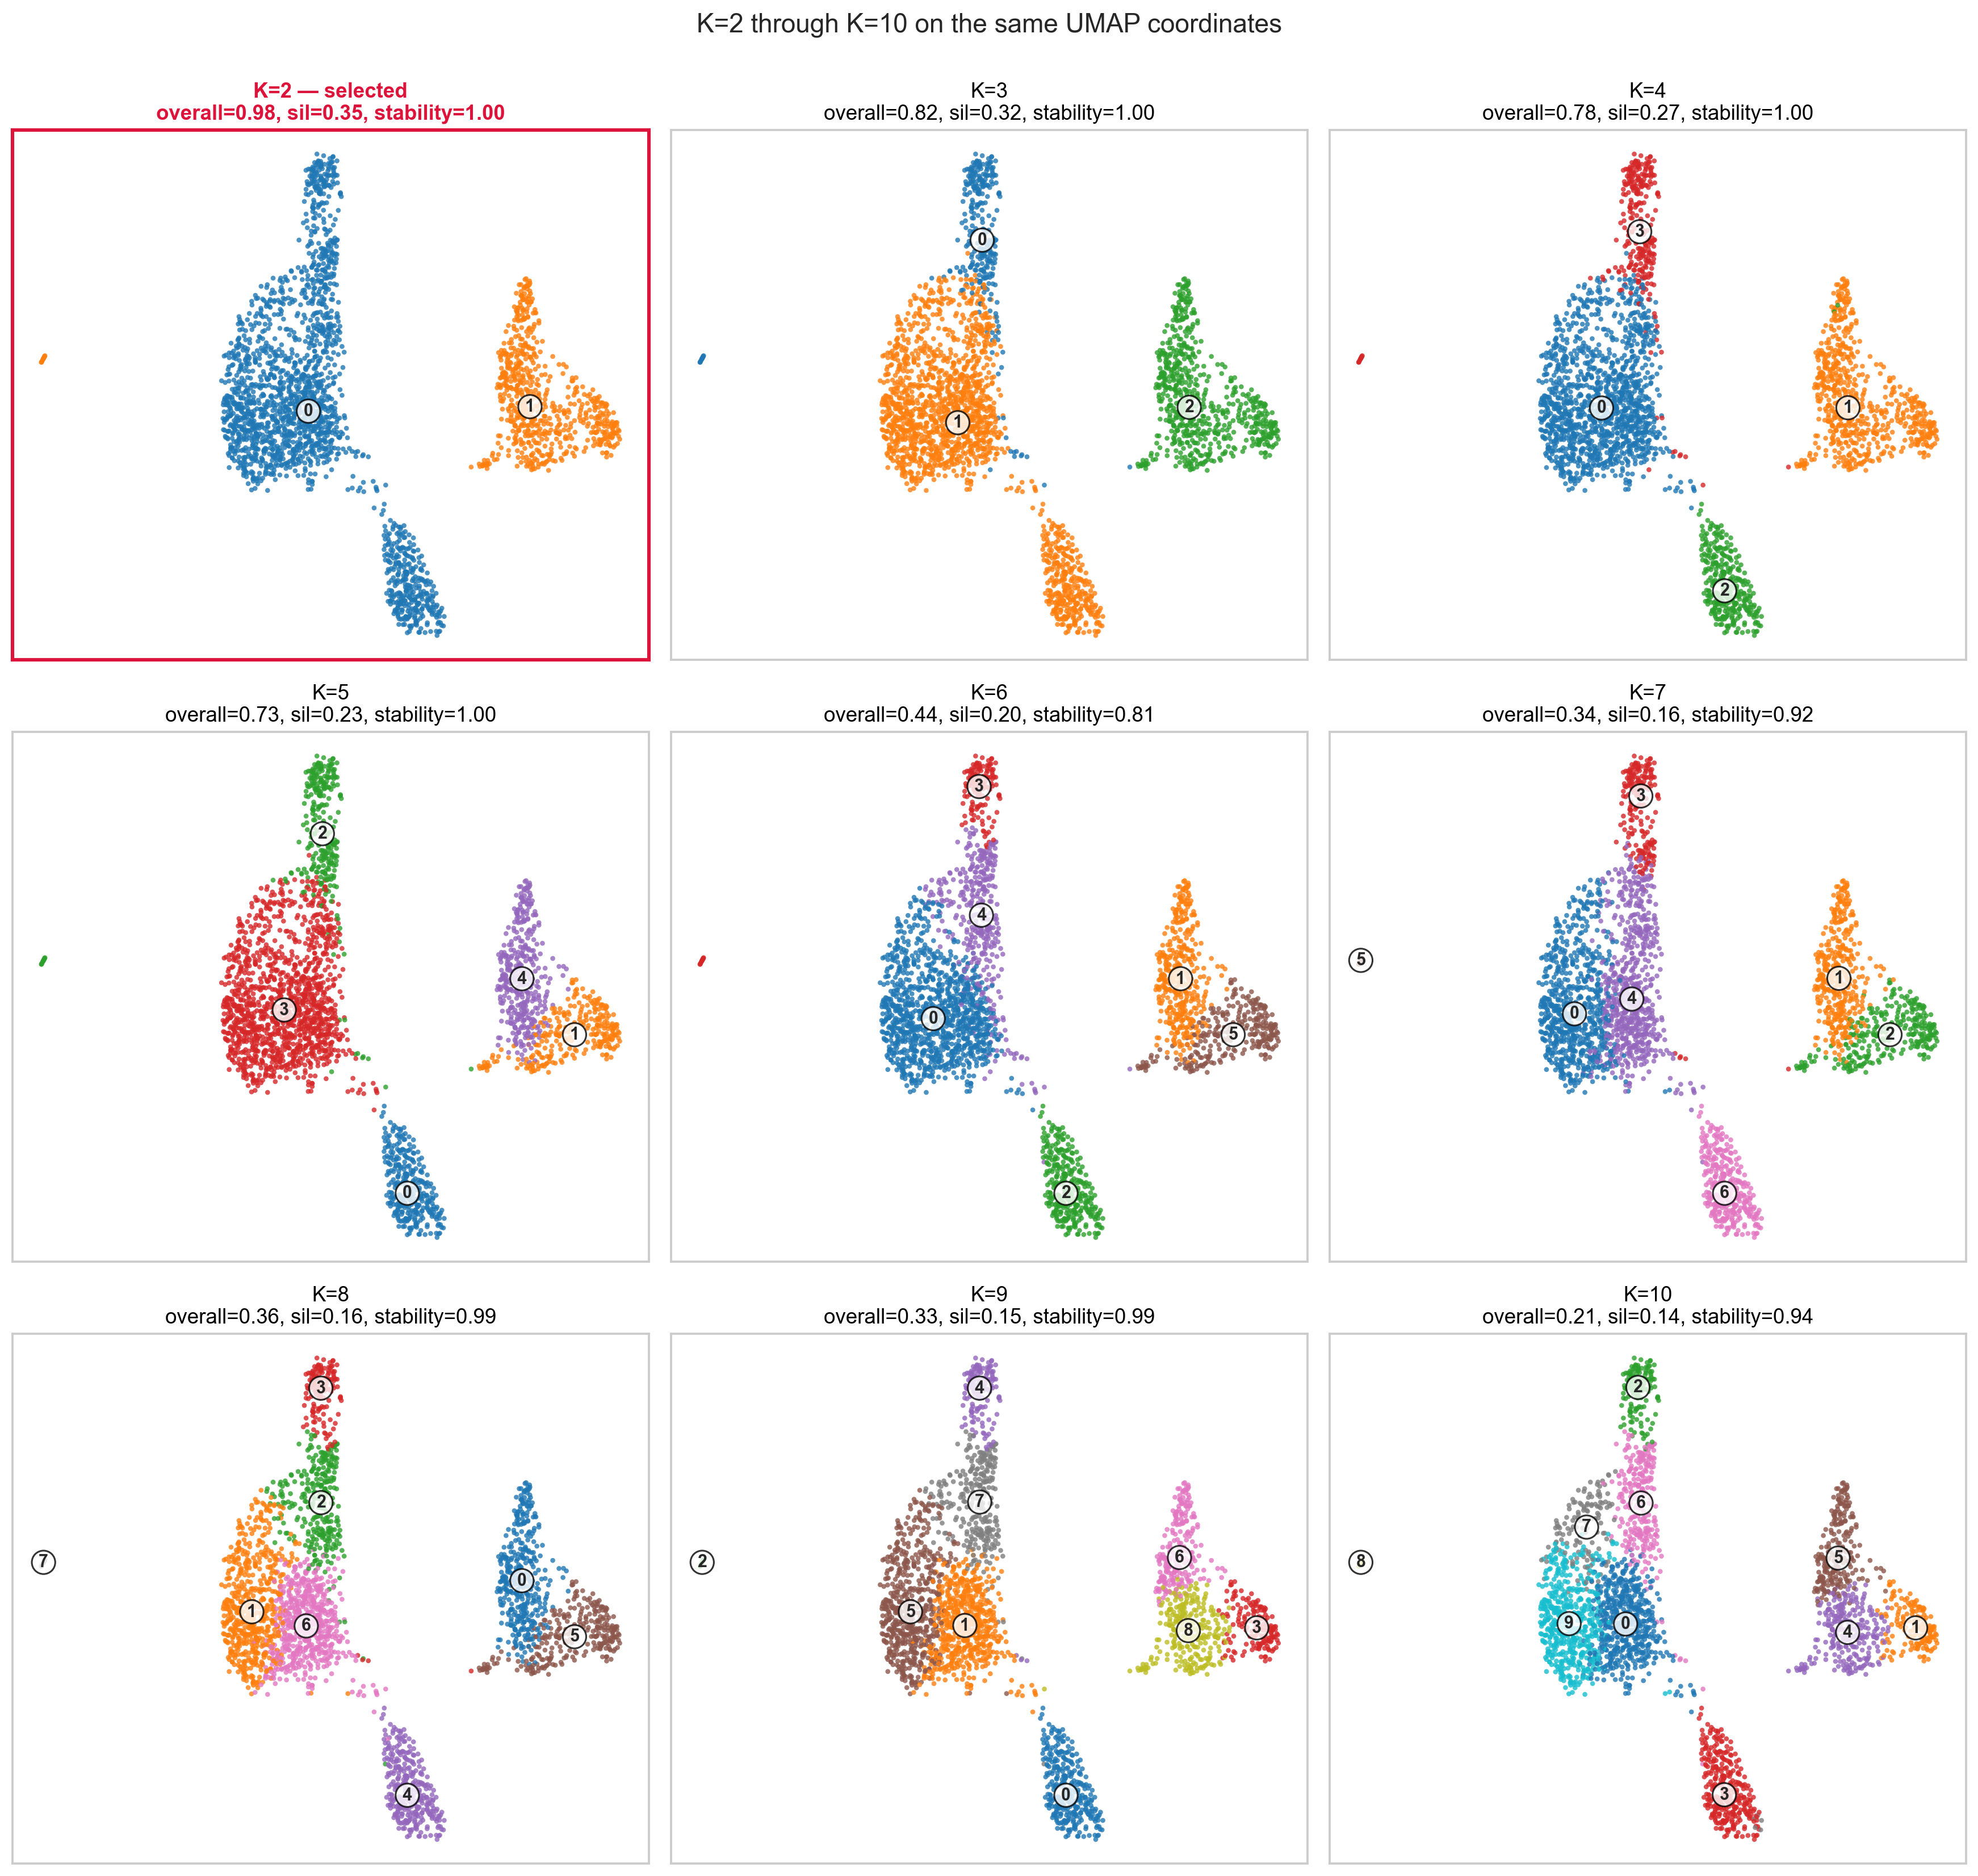

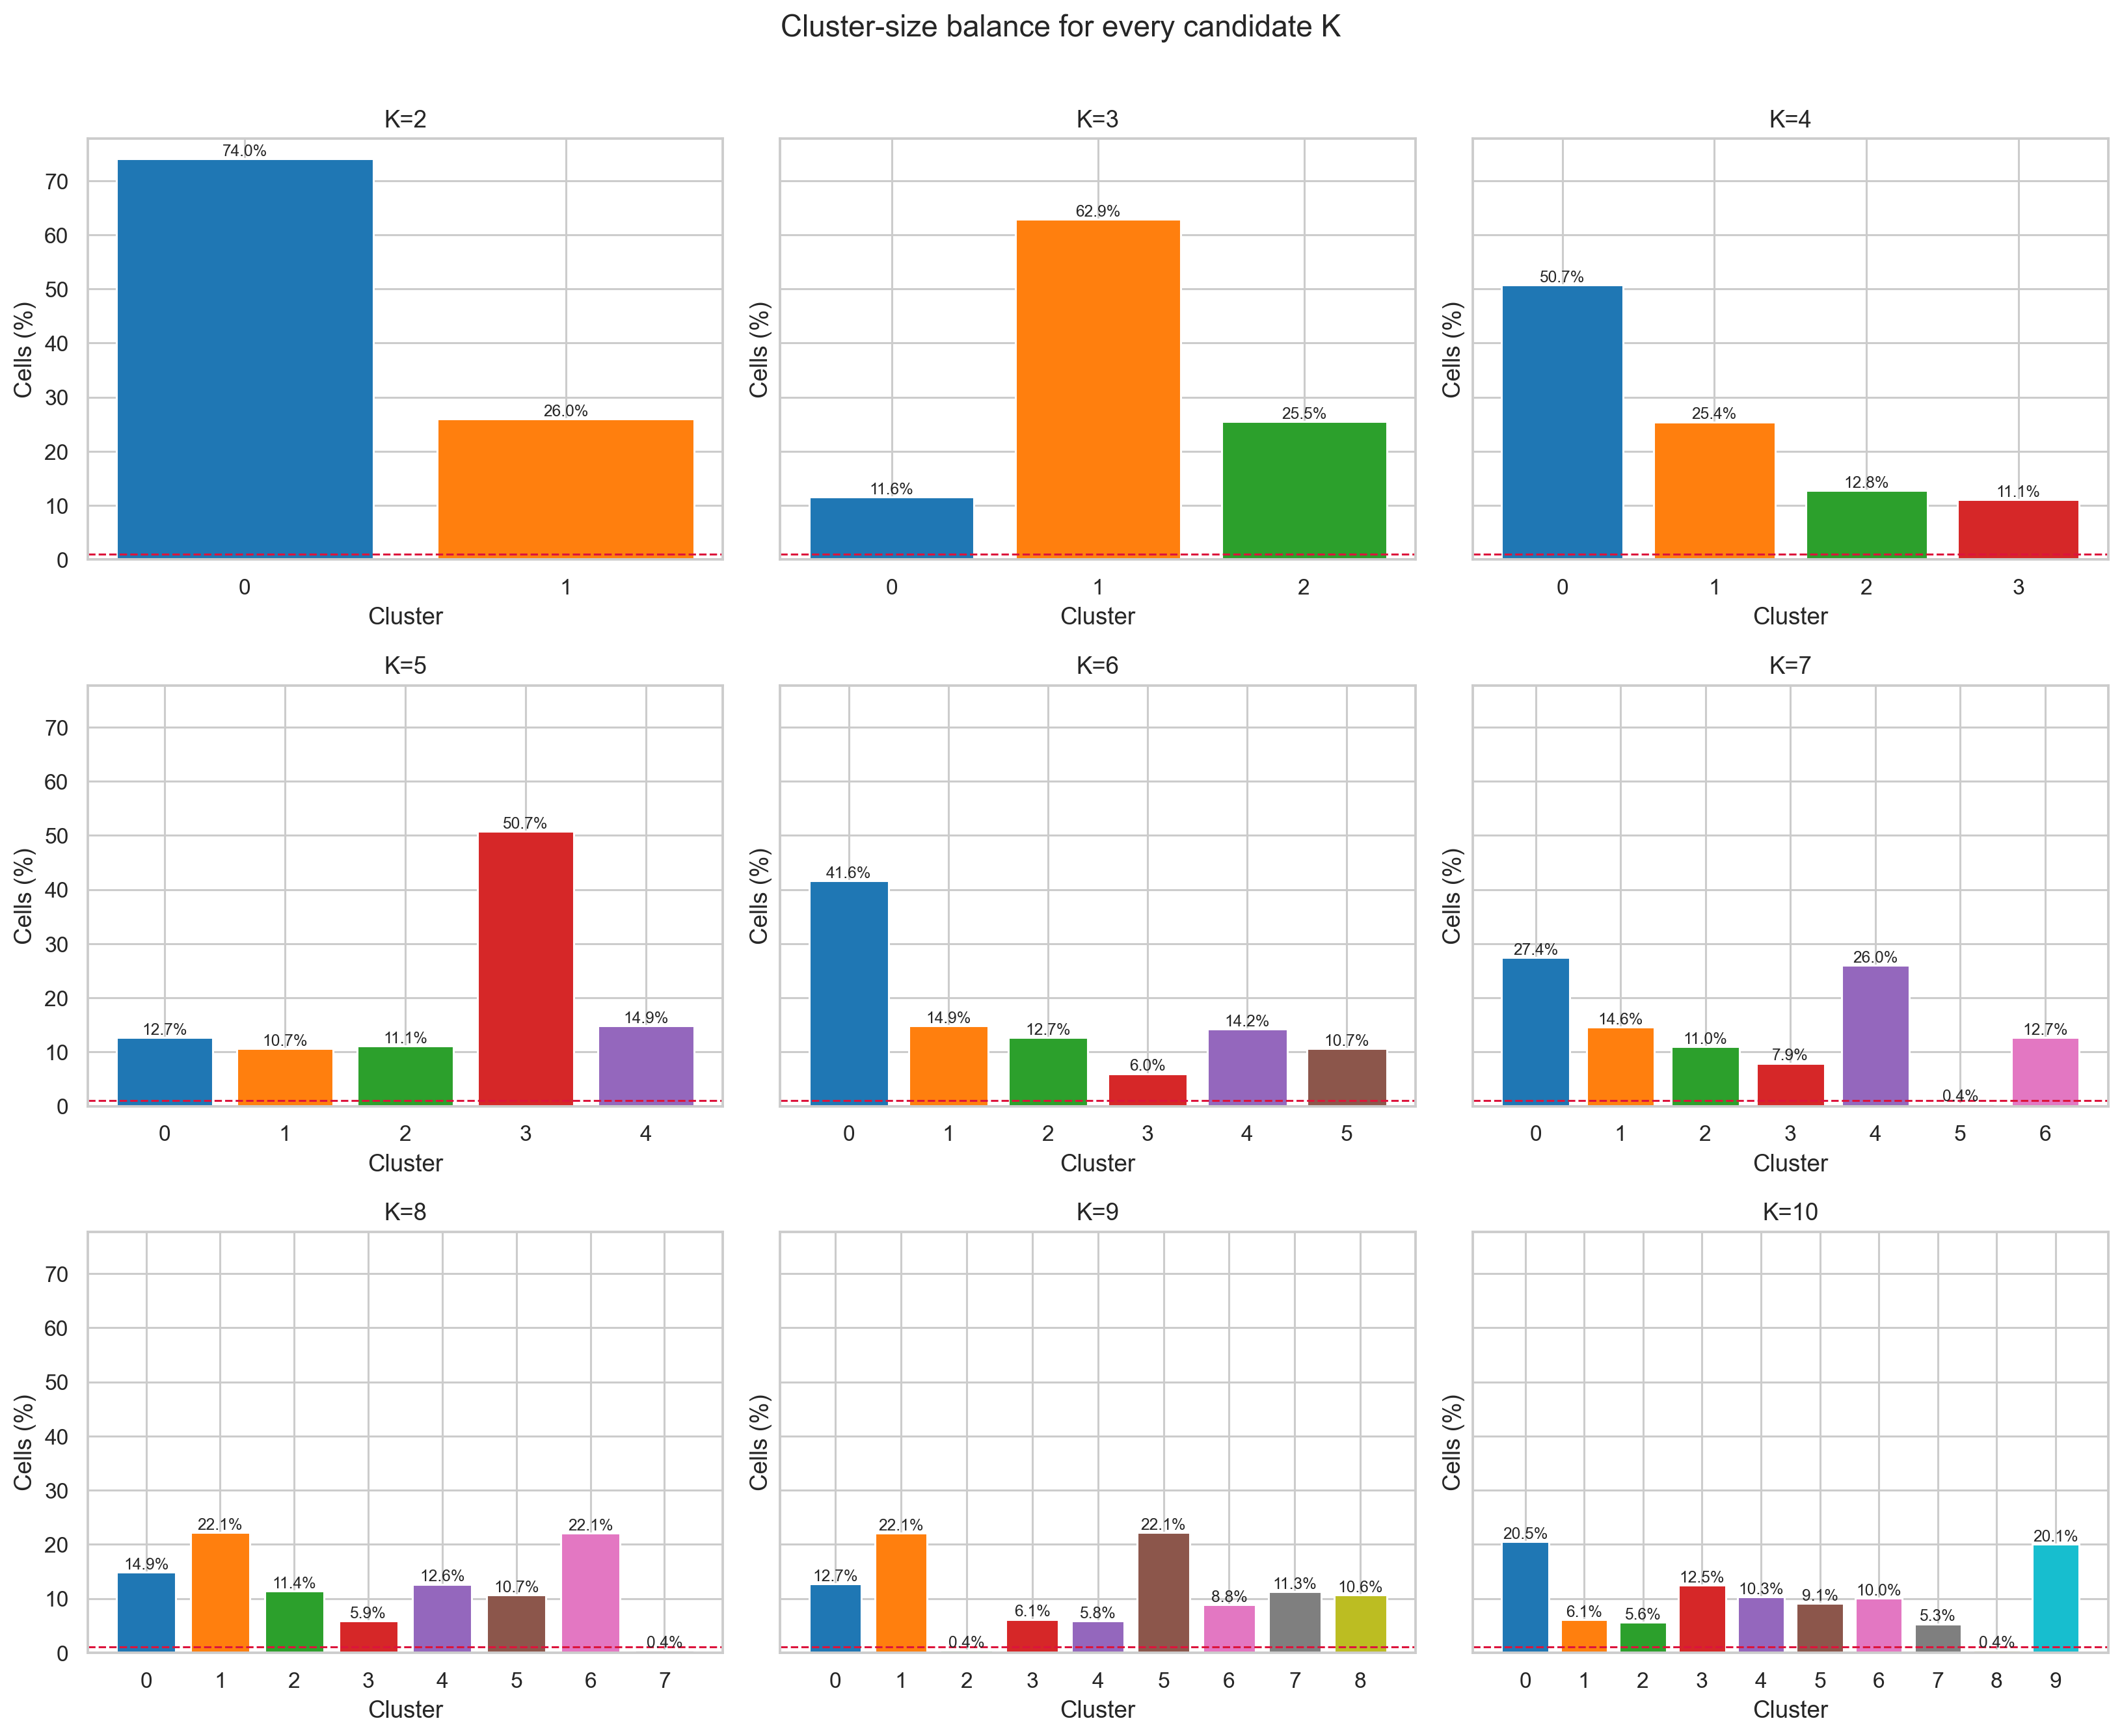

Selected K=2 from K=2–10 using the multi-evidence score. The geometric elbow suggests K=4; it is supporting rather than decisive evidence.


In [7]:
X_cluster = adata.obsm["X_pca"][:, :pcs_used]
model_rows = []
candidate_labels = {}
selection_qc_columns = [c for c in ["total_counts", "n_genes_by_counts", "pct_counts_mt"] if c in adata.obs]

def eta_squared(values, labels):
    """Fraction of numeric variance explained by categorical labels."""
    values = np.asarray(values, dtype=float)
    labels = np.asarray(labels)
    grand_mean = values.mean()
    total_ss = np.square(values - grand_mean).sum()
    if total_ss == 0:
        return 0.0
    between_ss = sum(
        np.sum(labels == group) * np.square(values[labels == group].mean() - grand_mean)
        for group in np.unique(labels)
    )
    return float(between_ss / total_ss)

for k in K_VALUES:
    model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_cluster)
    candidate_labels[k] = labels
    sample_size = min(SILHOUETTE_SAMPLE_SIZE, adata.n_obs)
    score = silhouette_score(
        X_cluster,
        labels,
        sample_size=sample_size if sample_size < adata.n_obs else None,
        random_state=RANDOM_STATE,
    )
    repeat_aris = []
    for seed in STABILITY_SEEDS:
        repeated_labels = KMeans(n_clusters=k, n_init=10, random_state=seed).fit_predict(X_cluster)
        repeat_aris.append(adjusted_rand_score(labels, repeated_labels))
    counts = np.bincount(labels, minlength=k)
    qc_effects = [eta_squared(adata.obs[metric], labels) for metric in selection_qc_columns]
    model_rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": score,
        "stability_ari": np.mean(repeat_aris),
        "smallest_cluster_cells": counts.min(),
        "smallest_cluster_percent": 100 * counts.min() / adata.n_obs,
        "max_qc_eta_squared": max(qc_effects, default=0.0),
    })

k_diagnostics = pd.DataFrame(model_rows).set_index("k")

# Scale both axes to [0, 1], then find the greatest distance below the line
# joining the endpoints of the monotonically decreasing inertia curve.
x = (k_diagnostics.index.to_numpy() - k_diagnostics.index.min()) / (k_diagnostics.index.max() - k_diagnostics.index.min())
y_raw = k_diagnostics["inertia"].to_numpy()
y = (y_raw - y_raw.min()) / (y_raw.max() - y_raw.min())
line_y = y[0] + (y[-1] - y[0]) * x
k_diagnostics["elbow_distance"] = line_y - y

elbow_k = int(k_diagnostics["elbow_distance"].idxmax())
k_diagnostics["viable_size"] = (
    (k_diagnostics["smallest_cluster_cells"] >= MIN_ACCEPTABLE_CLUSTER_CELLS)
    & (k_diagnostics["smallest_cluster_percent"] >= MIN_ACCEPTABLE_CLUSTER_PERCENT)
)
k_diagnostics["silhouette_rank"] = k_diagnostics["silhouette"].rank(pct=True)
k_diagnostics["stability_rank"] = k_diagnostics["stability_ari"].rank(pct=True)
k_diagnostics["size_rank"] = k_diagnostics["smallest_cluster_percent"].rank(pct=True)
k_diagnostics["qc_independence_rank"] = (-k_diagnostics["max_qc_eta_squared"]).rank(pct=True)
k_diagnostics["overall_score"] = (
    0.35 * k_diagnostics["silhouette_rank"]
    + 0.30 * k_diagnostics["stability_rank"]
    + 0.20 * k_diagnostics["size_rank"]
    + 0.15 * k_diagnostics["qc_independence_rank"]
)
eligible_scores = k_diagnostics["overall_score"].where(k_diagnostics["viable_size"])
if eligible_scores.notna().any():
    best_k = int(eligible_scores.idxmax())
else:
    best_k = int(k_diagnostics["overall_score"].idxmax())
    print("Warning: no candidate passed the minimum cluster-size rule; using the best overall diagnostic score.")

display(k_diagnostics.style.format({
    "inertia": "{:,.0f}", "silhouette": "{:.3f}", "stability_ari": "{:.3f}",
    "smallest_cluster_percent": "{:.1f}%", "max_qc_eta_squared": "{:.3f}",
    "elbow_distance": "{:.3f}", "overall_score": "{:.3f}",
}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_diagnostics.index, k_diagnostics["inertia"], marker="o")
axes[0].axvline(elbow_k, color="darkorange", linestyle="--", label=f"Geometric elbow: K={elbow_k}")
axes[0].axvline(best_k, color="crimson", linestyle=":", label=f"Best overall: K={best_k}")
axes[0].set(xlabel="Number of clusters (K)", ylabel="K-means inertia", title="Elbow method")
axes[0].legend()
axes[1].plot(k_diagnostics.index, k_diagnostics["silhouette"], marker="o")
axes[1].axvline(best_k, color="crimson", linestyle="--", label=f"Best overall: K={best_k}")
axes[1].set(xlabel="Number of clusters (K)", ylabel="Mean silhouette score", title="Silhouette method")
axes[1].legend()
plt.tight_layout()
plt.show()

# Plot every candidate on identical UMAP coordinates. Numeric labels mark
# cluster centroids, making splits and merged populations easy to compare.
umap = adata.obsm["X_umap"]
fig, axes = plt.subplots(3, 3, figsize=(16, 15), sharex=True, sharey=True)
for axis, k in zip(axes.flat, K_VALUES):
    labels = candidate_labels[k]
    axis.scatter(
        umap[:, 0], umap[:, 1], c=labels, cmap="tab10",
        vmin=0, vmax=9, s=8, alpha=0.8, linewidths=0,
    )
    for cluster in range(k):
        center = np.median(umap[labels == cluster], axis=0)
        axis.text(
            center[0], center[1], str(cluster), ha="center", va="center",
            fontsize=10, fontweight="bold",
            bbox={"boxstyle": "circle,pad=0.2", "facecolor": "white", "alpha": 0.8, "edgecolor": "black"},
        )
    selected_text = " — selected" if k == best_k else ""
    axis.set_title(
        f"K={k}{selected_text}\n"
        f"overall={k_diagnostics.loc[k, 'overall_score']:.2f}, "
        f"sil={k_diagnostics.loc[k, 'silhouette']:.2f}, "
        f"stability={k_diagnostics.loc[k, 'stability_ari']:.2f}",
        color="crimson" if k == best_k else "black",
        fontweight="bold" if k == best_k else "normal",
    )
    axis.set(xticks=[], yticks=[])
    if k == best_k:
        for spine in axis.spines.values():
            spine.set_visible(True)
            spine.set_color("crimson")
            spine.set_linewidth(2)
plt.suptitle("K=2 through K=10 on the same UMAP coordinates", fontsize=15, y=1.0)
plt.tight_layout()
plt.show()

# A visually attractive split can still create an implausibly tiny cluster.
# These bars show the percentage of cells assigned to every cluster for each K.
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharey=True)
for axis, k in zip(axes.flat, K_VALUES):
    counts = pd.Series(candidate_labels[k]).value_counts().sort_index()
    percentages = 100 * counts / adata.n_obs
    colors = [plt.cm.tab10(i) for i in range(k)]
    axis.bar(percentages.index.astype(str), percentages.values, color=colors)
    axis.axhline(MIN_ACCEPTABLE_CLUSTER_PERCENT, color="crimson", linestyle="--", linewidth=1)
    axis.set(title=f"K={k}", xlabel="Cluster", ylabel="Cells (%)")
    for index, value in enumerate(percentages.values):
        axis.text(index, value, f"{value:.1f}%", ha="center", va="bottom", fontsize=8)
plt.suptitle("Cluster-size balance for every candidate K", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print(
    f"Selected K={best_k} from K=2–10 using the multi-evidence score. "
    f"The geometric elbow suggests K={elbow_k}; it is supporting rather than decisive evidence."
)

## Final K-means clusters, UMAP, and t-SNE

K-means operates on the PCA coordinates used above. UMAP and t-SNE are independently calculated views colored by those same fixed labels. Agreement across views supports visually coherent clusters; disagreement warns that an apparent island may be embedding-specific.

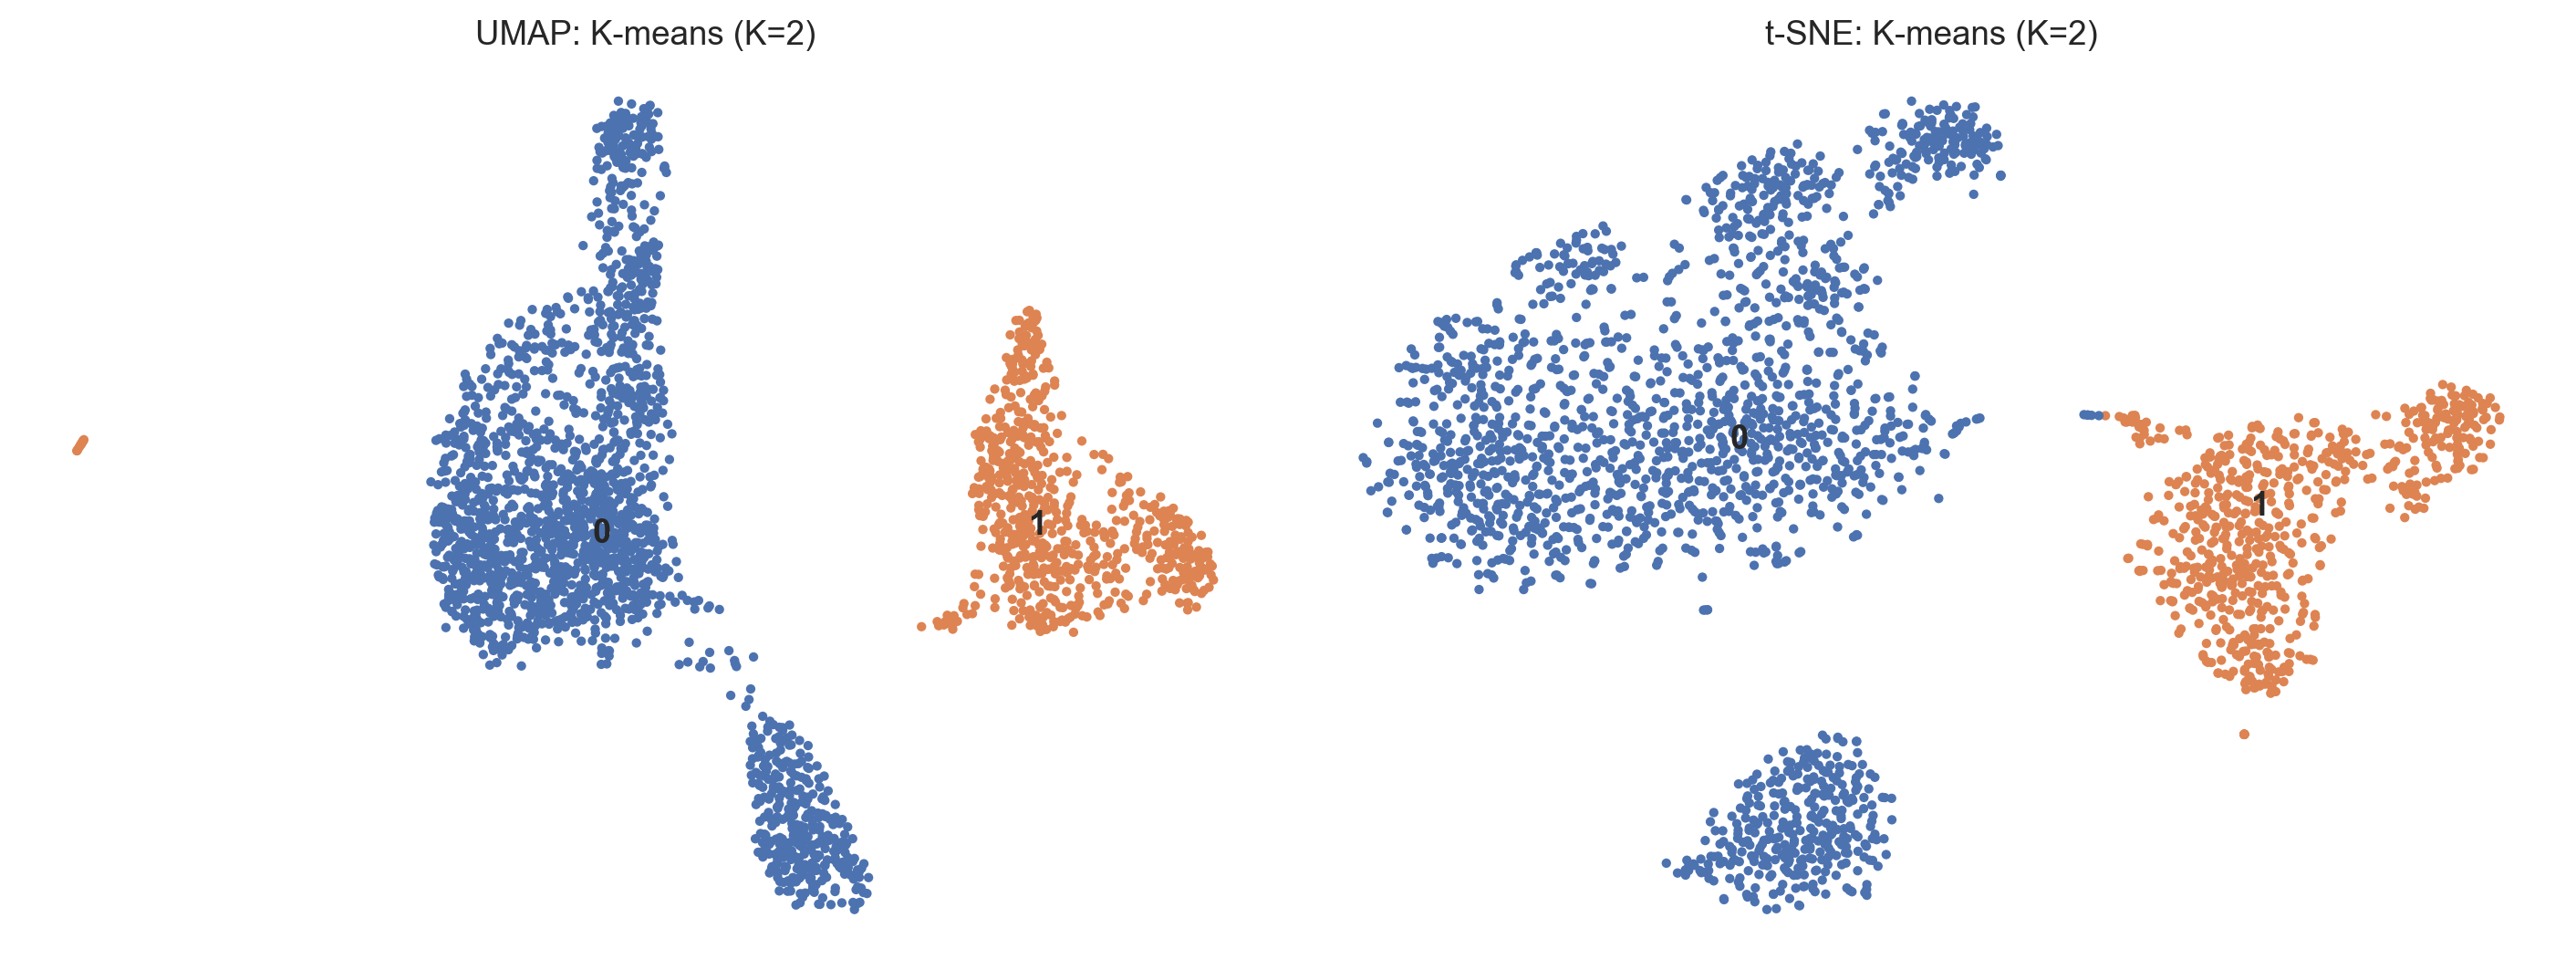

In [8]:
adata.obs["kmeans"] = pd.Categorical(candidate_labels[best_k].astype(str))

perplexity = min(30, max(5, (adata.n_obs - 1) // 3))
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    max_iter=1_000,
    random_state=RANDOM_STATE,
)
adata.obsm["X_tsne"] = tsne.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc.pl.umap(adata, color="kmeans", legend_loc="on data", title=f"UMAP: K-means (K={best_k})", ax=axes[0], show=False)
sc.pl.tsne(adata, color="kmeans", legend_loc="on data", title=f"t-SNE: K-means (K={best_k})", ax=axes[1], show=False)
plt.tight_layout()
plt.show()

## Cluster sizes and QC comparisons

Very small clusters can represent rare biology, outliers, or over-clustering. Systematic differences in counts, detected genes, or mitochondrial percentage can indicate that technical quality contributes to separation.

,cells,percent
kmeans,,
0,1953,74.0%
1,685,26.0%


total_counts                           n_genes_by_counts          \
             median         mean          std            median    mean   
kmeans                                                                    
0            2150.0  2209.360107   766.090027             803.0  803.97   
1            2704.0  2831.949951  1348.030029             960.0  975.88   

               pct_counts_mt              
           std        median  mean   std  
kmeans                                    
0       205.18          1.91  2.04  0.85  
1       352.22          2.26  2.33  0.80

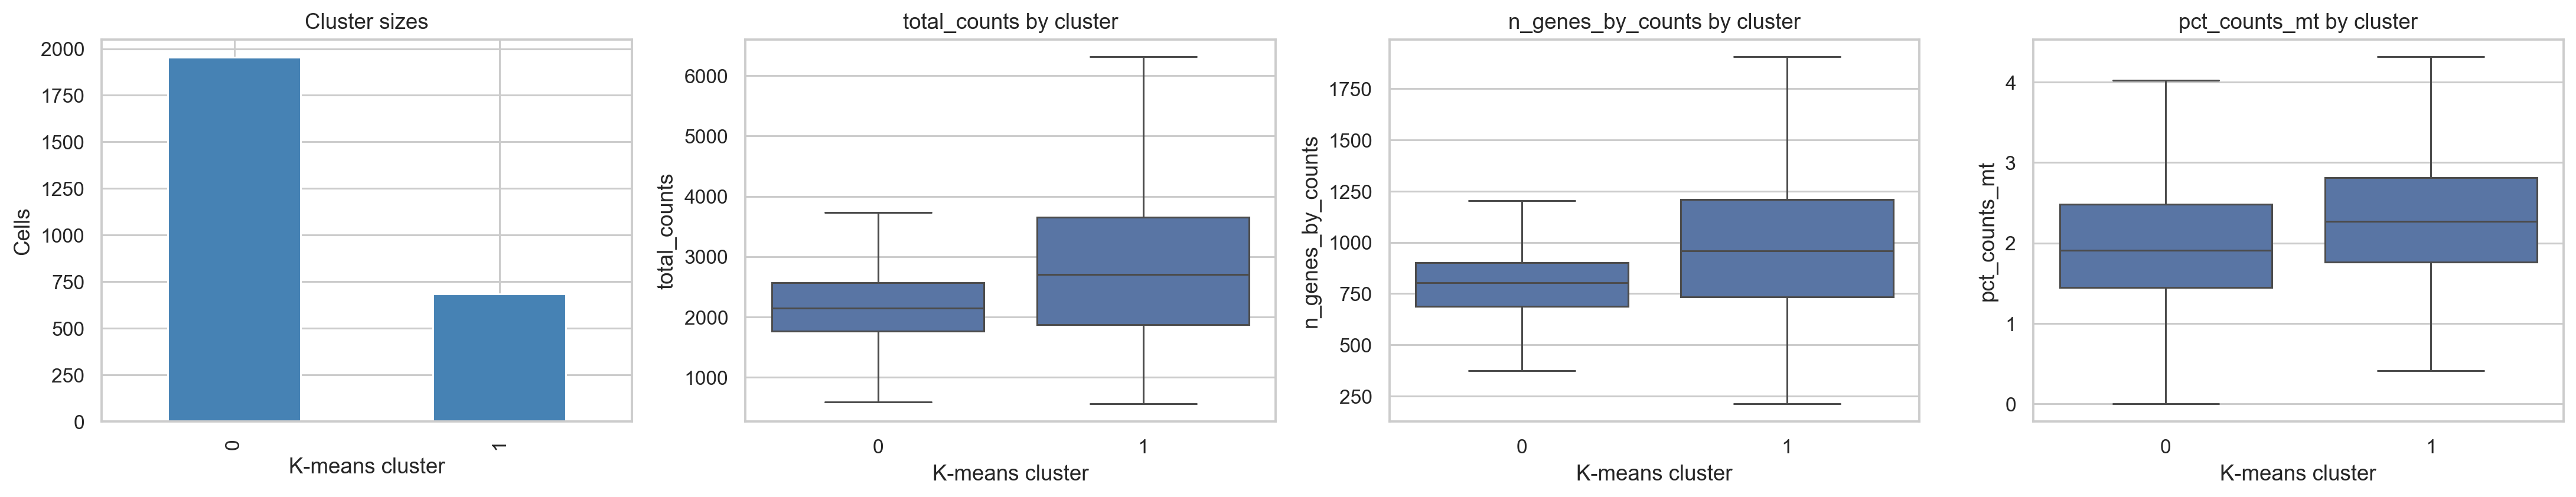

In [9]:
cluster_sizes = adata.obs["kmeans"].value_counts().sort_index().rename("cells").to_frame()
cluster_sizes["percent"] = 100 * cluster_sizes["cells"] / adata.n_obs
display(cluster_sizes.style.format({"percent": "{:.1f}%"}))

qc_columns = [c for c in ["total_counts", "n_genes_by_counts", "pct_counts_mt"] if c in adata.obs]
qc_by_cluster = adata.obs.groupby("kmeans", observed=True)[qc_columns].agg(["median", "mean", "std"])
display(qc_by_cluster.round(2))

fig, axes = plt.subplots(1, 1 + len(qc_columns), figsize=(5 * (1 + len(qc_columns)), 4))
cluster_sizes["cells"].plot.bar(ax=axes[0], color="steelblue")
axes[0].set(xlabel="K-means cluster", ylabel="Cells", title="Cluster sizes")
for axis, metric in zip(axes[1:], qc_columns):
    sns.boxplot(data=adata.obs, x="kmeans", y=metric, ax=axis, showfliers=False)
    axis.set(title=f"{metric} by cluster", xlabel="K-means cluster")
plt.tight_layout()
plt.show()

## Genes most highly expressed in each cluster

Wilcoxon rank-sum tests compare each cluster with all remaining cells using every normalized gene retained in `adata.raw`, not only the 2,000 PCA features. Adjusted p-values control the false-discovery rate. Large positive log fold changes with substantial within-cluster expression prevalence are the strongest candidate markers.

ranking genes
    finished (0:00:09)
Cluster 0


,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,MALAT1,35.396660,1.644802,1.921897e-274,2.385948e-271,1.000000,0.998540
1,RPS27A,33.800793,2.165486,1.919994e-250,1.379970e-247,0.996416,0.909489
2,RPS27,32.599388,1.359522,4.183894e-233,2.484142e-230,0.997952,0.981022
3,RPL23A,32.184170,1.361467,2.939343e-227,1.672486e-224,0.997952,0.972263
4,RPSA,31.121550,1.919249,1.231047e-212,6.465838e-210,0.989759,0.870073
5,RPL9,31.119772,1.603735,1.301165e-212,6.581004e-210,0.994368,0.929927
6,RPL3,30.903009,1.201135,1.088263e-209,5.124594e-207,0.998976,0.986861
7,PTPRCAP,30.285721,4.870055,1.767557e-201,8.045919e-199,0.822325,0.127007
8,RPL21,29.965328,1.303194,2.778326e-197,1.223898e-194,0.997440,0.979562
9,RPS3A,29.778767,1.710197,7.358939e-195,3.045263e-192,0.992832,0.945985


Cluster 1


,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,FTH1,38.642879,3.201530,0.000000e+00,0.000000e+00,1.000000,0.986175
1,CST3,38.397171,6.895319,0.000000e+00,0.000000e+00,0.988321,0.190988
2,FTL,38.231712,3.689746,0.000000e+00,0.000000e+00,1.000000,0.986175
3,LYZ,37.602295,5.967430,1.971656e-309,6.731232e-306,0.986861,0.470558
4,TYROBP,37.418797,6.226941,1.933351e-306,5.280369e-303,0.979562,0.193548
5,LST1,36.507233,6.054039,8.514542e-292,1.937910e-288,0.951825,0.147977
6,AIF1,36.408092,5.875082,3.170064e-290,6.184343e-287,0.953285,0.171531
7,LGALS1,35.754482,4.934463,5.635516e-280,9.619826e-277,0.967883,0.304659
8,OAZ1,35.559292,2.292215,5.969751e-277,9.058103e-274,0.997080,0.882232
9,S100A9,35.477234,7.101723,1.103418e-275,1.506828e-272,0.935766,0.154634


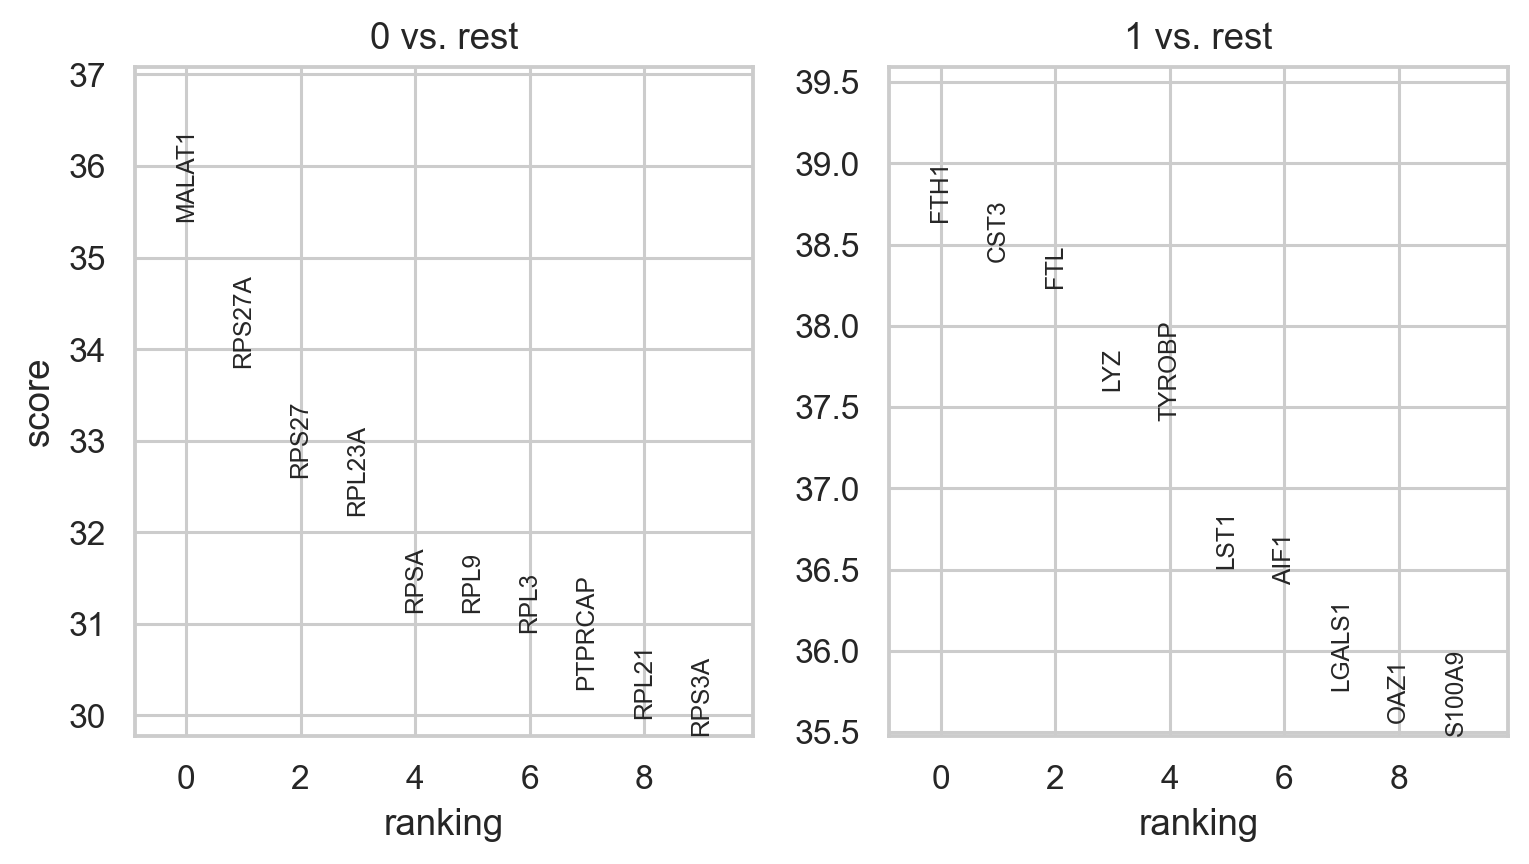

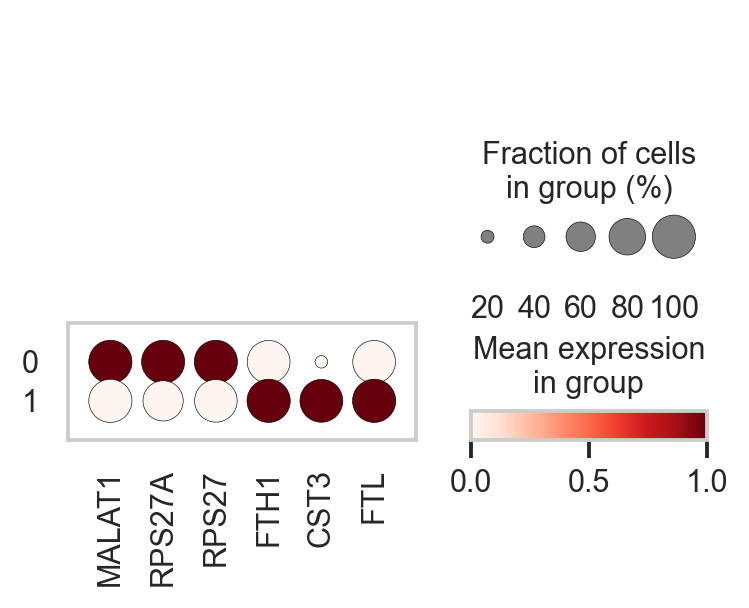

In [10]:
if adata.raw is None:
    raise ValueError("The Phase 1 object must contain adata.raw for all-gene marker testing.")

sc.tl.rank_genes_groups(
    adata,
    groupby="kmeans",
    method="wilcoxon",
    use_raw=True,
    pts=True,
    corr_method="benjamini-hochberg",
)

marker_tables = {}
for cluster in adata.obs["kmeans"].cat.categories:
    table = sc.get.rank_genes_groups_df(adata, group=cluster).head(50)
    marker_tables[str(cluster)] = table
    print(f"Cluster {cluster}")
    display(table.head(N_MARKERS))

sc.pl.rank_genes_groups(adata, n_genes=N_MARKERS, sharey=False)
top_marker_names = list(dict.fromkeys(
    gene for cluster in adata.obs["kmeans"].cat.categories
    for gene in marker_tables[str(cluster)]["names"].head(3)
))
sc.pl.dotplot(adata, top_marker_names, groupby="kmeans", use_raw=True, standard_scale="var")

## Why do particular RNA markers dominate certain clusters?

A gene can dominate a cluster for several non-exclusive reasons:

- **Cell identity:** lineage programs create strong, specific markers (for example, immunoglobulin, cytotoxic, or myeloid genes).
- **Expression prevalence:** a transcript expressed in nearly every cell of one cluster but few cells elsewhere receives a strong rank.
- **Abundance:** highly expressed transcripts contribute many molecules and can strongly influence variance-based embeddings.
- **Cell state:** interferon response, activation, stress, or cell-cycle programs can cut across canonical cell types.
- **Technical effects:** mitochondrial genes can reflect stress; ribosomal genes and total counts can reflect library complexity; ambient RNA can produce abundant but weakly specific signal.

The next cell quantifies specificity, prevalence, abundance, gene category, and correlations with QC. A convincing biological marker should combine high fold change and within-cluster prevalence with a clear between-cluster contrast, without being explained primarily by a QC metric.

,cluster,gene,logfoldchange,adjusted_p,mean_in_cluster,mean_outside,pct_expressing_in,pct_expressing_out,mitochondrial,ribosomal,corr_total_counts,corr_n_genes_by_counts,corr_pct_counts_mt,prevalence_gap,possible_technical_driver
7,0,PTPRCAP,4.87,8.05e-199,2.01,0.20,82.2%,12.7%,False,False,-0.166674,-0.120126,-0.052882,69.5 pp,False
1,0,RPS27A,2.17,1.38e-247,4.02,2.58,99.6%,90.9%,False,True,-0.063774,-0.133725,-0.008532,8.7 pp,True
4,0,RPSA,1.92,6.47e-210,3.52,2.27,99.0%,87.0%,False,True,0.079789,0.011154,-0.153261,12.0 pp,True
9,0,RPS3A,1.71,3.05e-192,4.05,2.91,99.3%,94.6%,False,True,-0.015368,-0.105948,0.038525,4.7 pp,True
0,0,MALAT1,1.64,2.39e-271,5.72,4.59,100.0%,99.9%,False,False,-0.279896,-0.280779,-0.040631,0.1 pp,False
5,0,RPL9,1.60,6.58e-210,3.78,2.71,99.4%,93.0%,False,True,0.004303,-0.086358,-0.046537,6.4 pp,True
3,0,RPL23A,1.36,1.67e-224,4.05,3.13,99.8%,97.2%,False,True,-0.042550,-0.126774,-0.094962,2.6 pp,True
2,0,RPS27,1.36,2.48e-230,4.38,3.46,99.8%,98.1%,False,True,-0.092480,-0.194467,-0.138877,1.7 pp,True
8,0,RPL21,1.30,1.22e-194,4.10,3.22,99.7%,98.0%,False,True,-0.084795,-0.176455,-0.035888,1.8 pp,True
6,0,RPL3,1.20,5.12e-207,4.39,3.57,99.9%,98.7%,False,True,-0.027122,-0.122175,-0.161052,1.2 pp,True


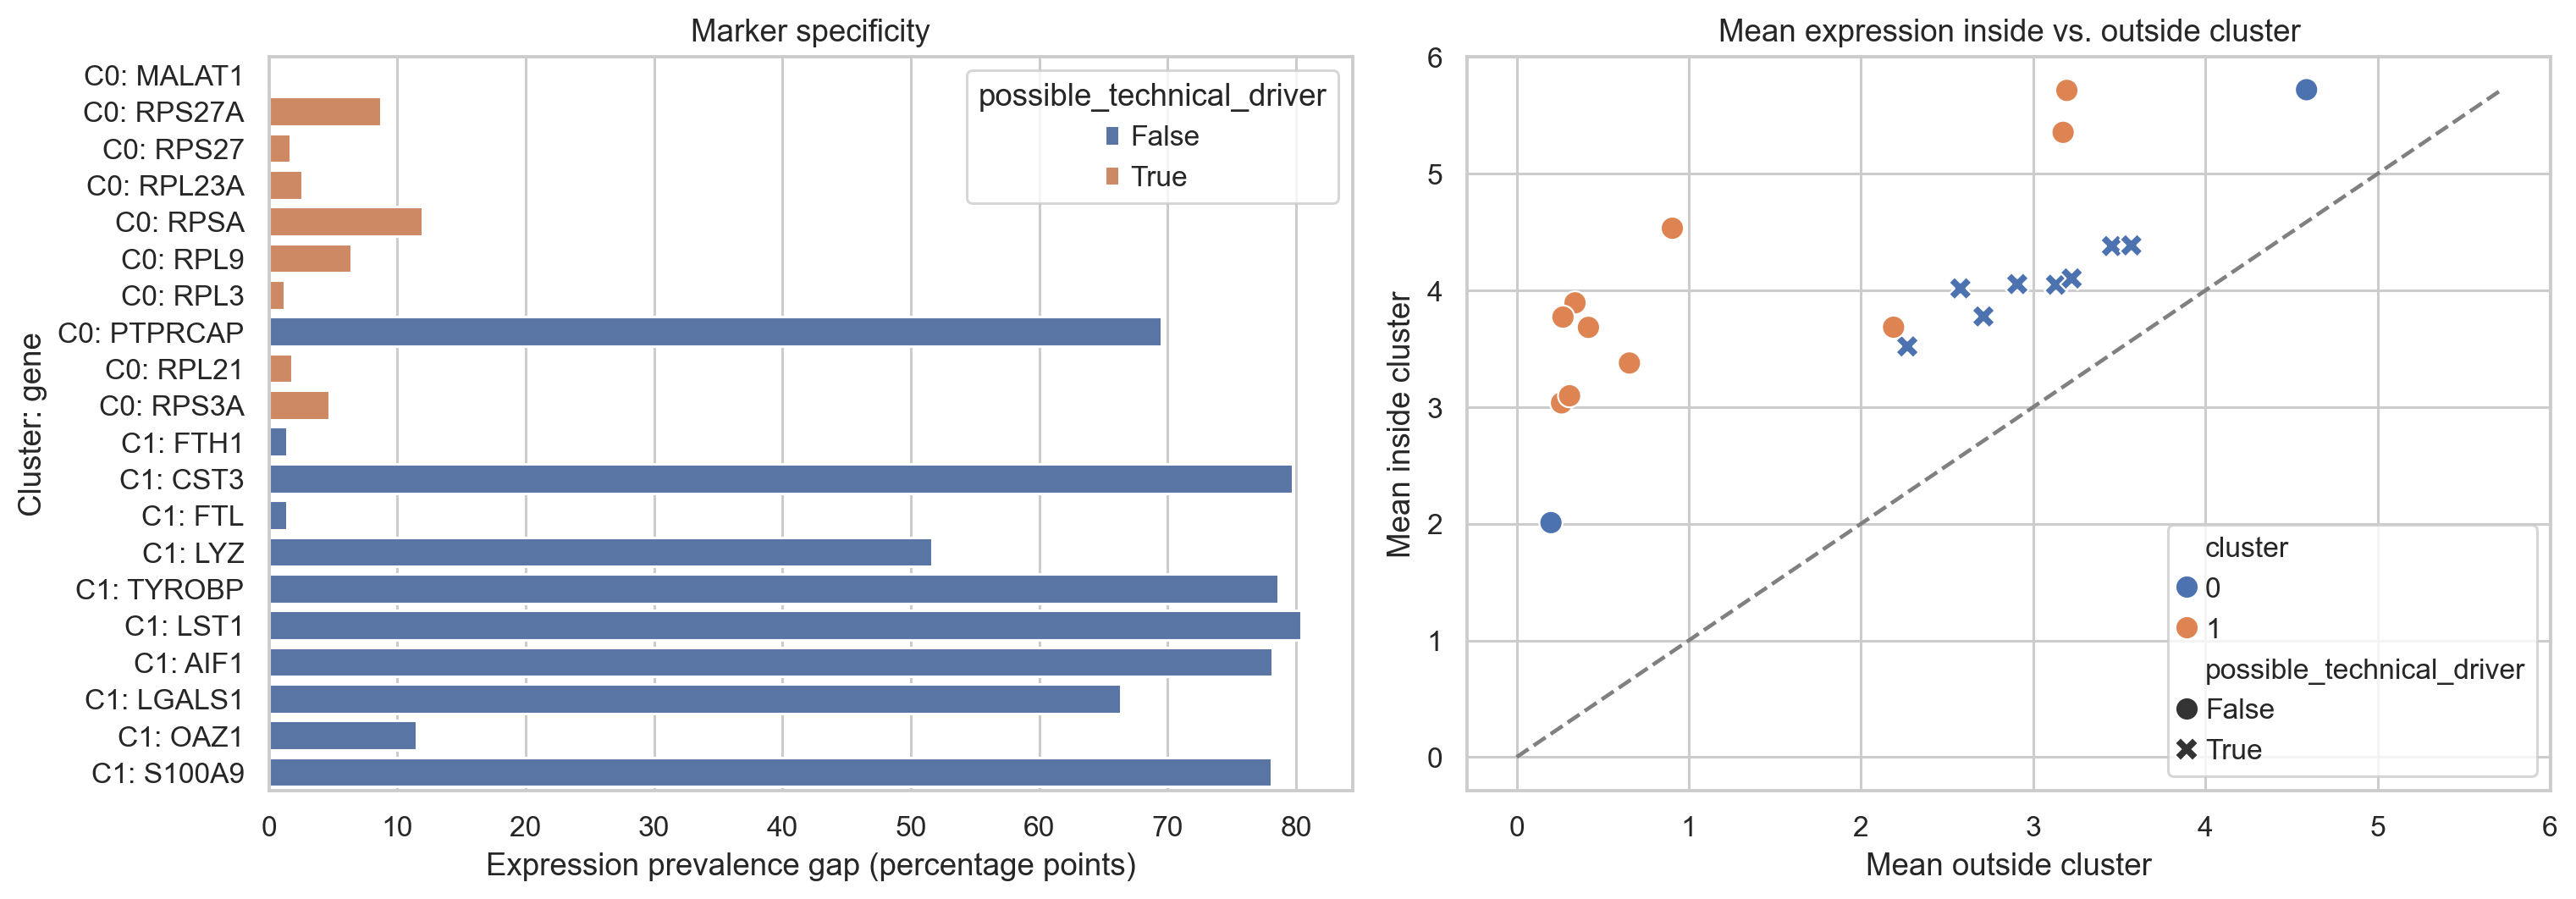

,mitochondrial,ribosomal,mitochondrial_or_ribosomal_top_markers
cluster,,,
0,0,8,8
1,0,0,0


In [11]:
raw_gene_names = pd.Index(adata.raw.var_names)
raw_X = adata.raw.X

dominance_rows = []
for cluster in adata.obs["kmeans"].cat.categories:
    top = marker_tables[str(cluster)].head(N_MARKERS).copy()
    for _, row in top.iterrows():
        gene = row["names"]
        gene_idx = raw_gene_names.get_loc(gene)
        values = raw_X[:, gene_idx]
        values = values.toarray().ravel() if sparse.issparse(values) else np.asarray(values).ravel()
        in_cluster = adata.obs["kmeans"].to_numpy() == cluster
        correlations = {}
        for metric in qc_columns:
            correlations[f"corr_{metric}"] = np.corrcoef(values, adata.obs[metric].to_numpy())[0, 1]
        dominance_rows.append({
            "cluster": str(cluster),
            "gene": gene,
            "logfoldchange": row.get("logfoldchanges", np.nan),
            "adjusted_p": row.get("pvals_adj", np.nan),
            "mean_in_cluster": values[in_cluster].mean(),
            "mean_outside": values[~in_cluster].mean(),
            "pct_expressing_in": 100 * np.mean(values[in_cluster] > 0),
            "pct_expressing_out": 100 * np.mean(values[~in_cluster] > 0),
            "mitochondrial": gene.upper().startswith("MT-"),
            "ribosomal": gene.upper().startswith(("RPL", "RPS")),
            **correlations,
        })

dominance = pd.DataFrame(dominance_rows)
dominance["prevalence_gap"] = dominance["pct_expressing_in"] - dominance["pct_expressing_out"]
dominance["possible_technical_driver"] = dominance["mitochondrial"] | dominance["ribosomal"]
display(
    dominance.sort_values(["cluster", "logfoldchange"], ascending=[True, False])
    .style.format({
        "logfoldchange": "{:.2f}", "adjusted_p": "{:.2e}",
        "mean_in_cluster": "{:.2f}", "mean_outside": "{:.2f}",
        "pct_expressing_in": "{:.1f}%", "pct_expressing_out": "{:.1f}%",
        "prevalence_gap": "{:.1f} pp",
    })
)

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, 0.22 * len(dominance))))
plot_data = dominance.copy()
plot_data["cluster_gene"] = "C" + plot_data["cluster"] + ": " + plot_data["gene"]
sns.barplot(data=plot_data, y="cluster_gene", x="prevalence_gap", hue="possible_technical_driver", dodge=False, ax=axes[0])
axes[0].set(title="Marker specificity", xlabel="Expression prevalence gap (percentage points)", ylabel="Cluster: gene")
sns.scatterplot(data=plot_data, x="mean_outside", y="mean_in_cluster", hue="cluster", style="possible_technical_driver", s=80, ax=axes[1])
limit = max(plot_data["mean_in_cluster"].max(), plot_data["mean_outside"].max())
axes[1].plot([0, limit], [0, limit], color="grey", linestyle="--")
axes[1].set(title="Mean expression inside vs. outside cluster", xlabel="Mean outside cluster", ylabel="Mean inside cluster")
plt.tight_layout()
plt.show()

technical_summary = dominance.groupby("cluster")[["mitochondrial", "ribosomal", "possible_technical_driver"]].sum()
display(technical_summary.rename(columns={"possible_technical_driver": "mitochondrial_or_ribosomal_top_markers"}))

## Interpret and save

Use the following evidence together before assigning biological cell-type names:

1. The K=2–10 comparison supports a defensible K using silhouette, stability, viable cluster size, QC independence, and visual structure; the elbow is only corroborating evidence.
2. Clusters appear coherent across both UMAP and t-SNE.
3. Cluster sizes are plausible and clusters are not separated only by QC metrics.
4. Multiple concordant lineage markers support each interpretation; a single abundant RNA is not sufficient.
5. Marker dominance is specific to the cluster and is not primarily mitochondrial, ribosomal, or tightly correlated with library complexity.

The saved object contains PCA, neighbor graph, UMAP, t-SNE, K-means labels, and differential-expression results. The full normalized gene matrix remains in `.raw`.

In [12]:
adata.uns["kmeans_model_selection"] = {
    "k_values": k_diagnostics.index.to_numpy(),
    "inertia": k_diagnostics["inertia"].to_numpy(),
    "silhouette": k_diagnostics["silhouette"].to_numpy(),
    "geometric_elbow_k": elbow_k,
    "selected_k": best_k,
    "selection_rule": "best viable multi-evidence score: 35% silhouette, 30% stability, 20% minimum cluster size, 15% QC independence; geometric elbow reported only as supporting evidence",
    "random_state": RANDOM_STATE,
}
adata.write_h5ad(OUTPUT, compression="gzip")

final_summary = pd.Series({
    "cells": adata.n_obs,
    "PCA features": adata.n_vars,
    "PCs used": pcs_used,
    "nearest neighbors": N_NEIGHBORS,
    "geometric elbow K": elbow_k,
    "selected multi-evidence K": best_k,
    "clusters": adata.obs["kmeans"].nunique(),
    "output": str(OUTPUT),
}, name="Phase 2 result")
display(final_summary.to_frame())
print(f"Saved {OUTPUT.name} ({OUTPUT.stat().st_size / 1024**2:.1f} MB)")

,Phase 2 result
cells,2638
PCA features,2000
PCs used,30
nearest neighbors,15
geometric elbow K,4
selected multi-evidence K,2
clusters,2
output,/Users/Ema/Desktop/cosmos/26-the-backpropagato...


Saved pbmc3k_phase2_clustered.h5ad (31.2 MB)


## Leiden graph clustering

Leiden clustering detects communities directly in the nearest-neighbor graph, so it complements K-means, which assumes roughly spherical groups in PCA space. Leiden does not require a fixed number of clusters; its `resolution` parameter controls granularity. Higher resolutions generally produce more communities.

The following comparison tests six resolutions. It considers silhouette, stability across random seeds, viable minimum cluster size, QC independence, and visual coherence on the same UMAP. The selected Leiden result is then compared with K-means, but neither method should be accepted solely because it produces a higher numerical score—marker coherence and QC patterns still matter.

running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clust

,clusters,silhouette,stability_ari,smallest_cluster_cells,smallest_cluster_percent,max_qc_eta_squared,viable_size,silhouette_rank,stability_rank,size_rank,qc_independence_rank,overall_score
resolution,,,,,,,,,,,,
0.200000,5,0.269,0.876,11,0.4%,0.136,False,1.000000,0.166667,0.583333,1.000000,0.667
0.400000,6,0.221,0.984,11,0.4%,0.199,False,0.833333,1.000000,0.583333,0.833333,0.833
0.600000,9,0.147,0.958,11,0.4%,0.362,False,0.666667,0.833333,0.583333,0.666667,0.700
0.800000,10,0.141,0.946,11,0.4%,0.432,False,0.500000,0.666667,0.583333,0.500000,0.567
1.000000,11,0.136,0.914,11,0.4%,0.532,False,0.333333,0.500000,0.583333,0.333333,0.433
1.200000,11,0.135,0.912,11,0.4%,0.543,False,0.166667,0.333333,0.583333,0.166667,0.300


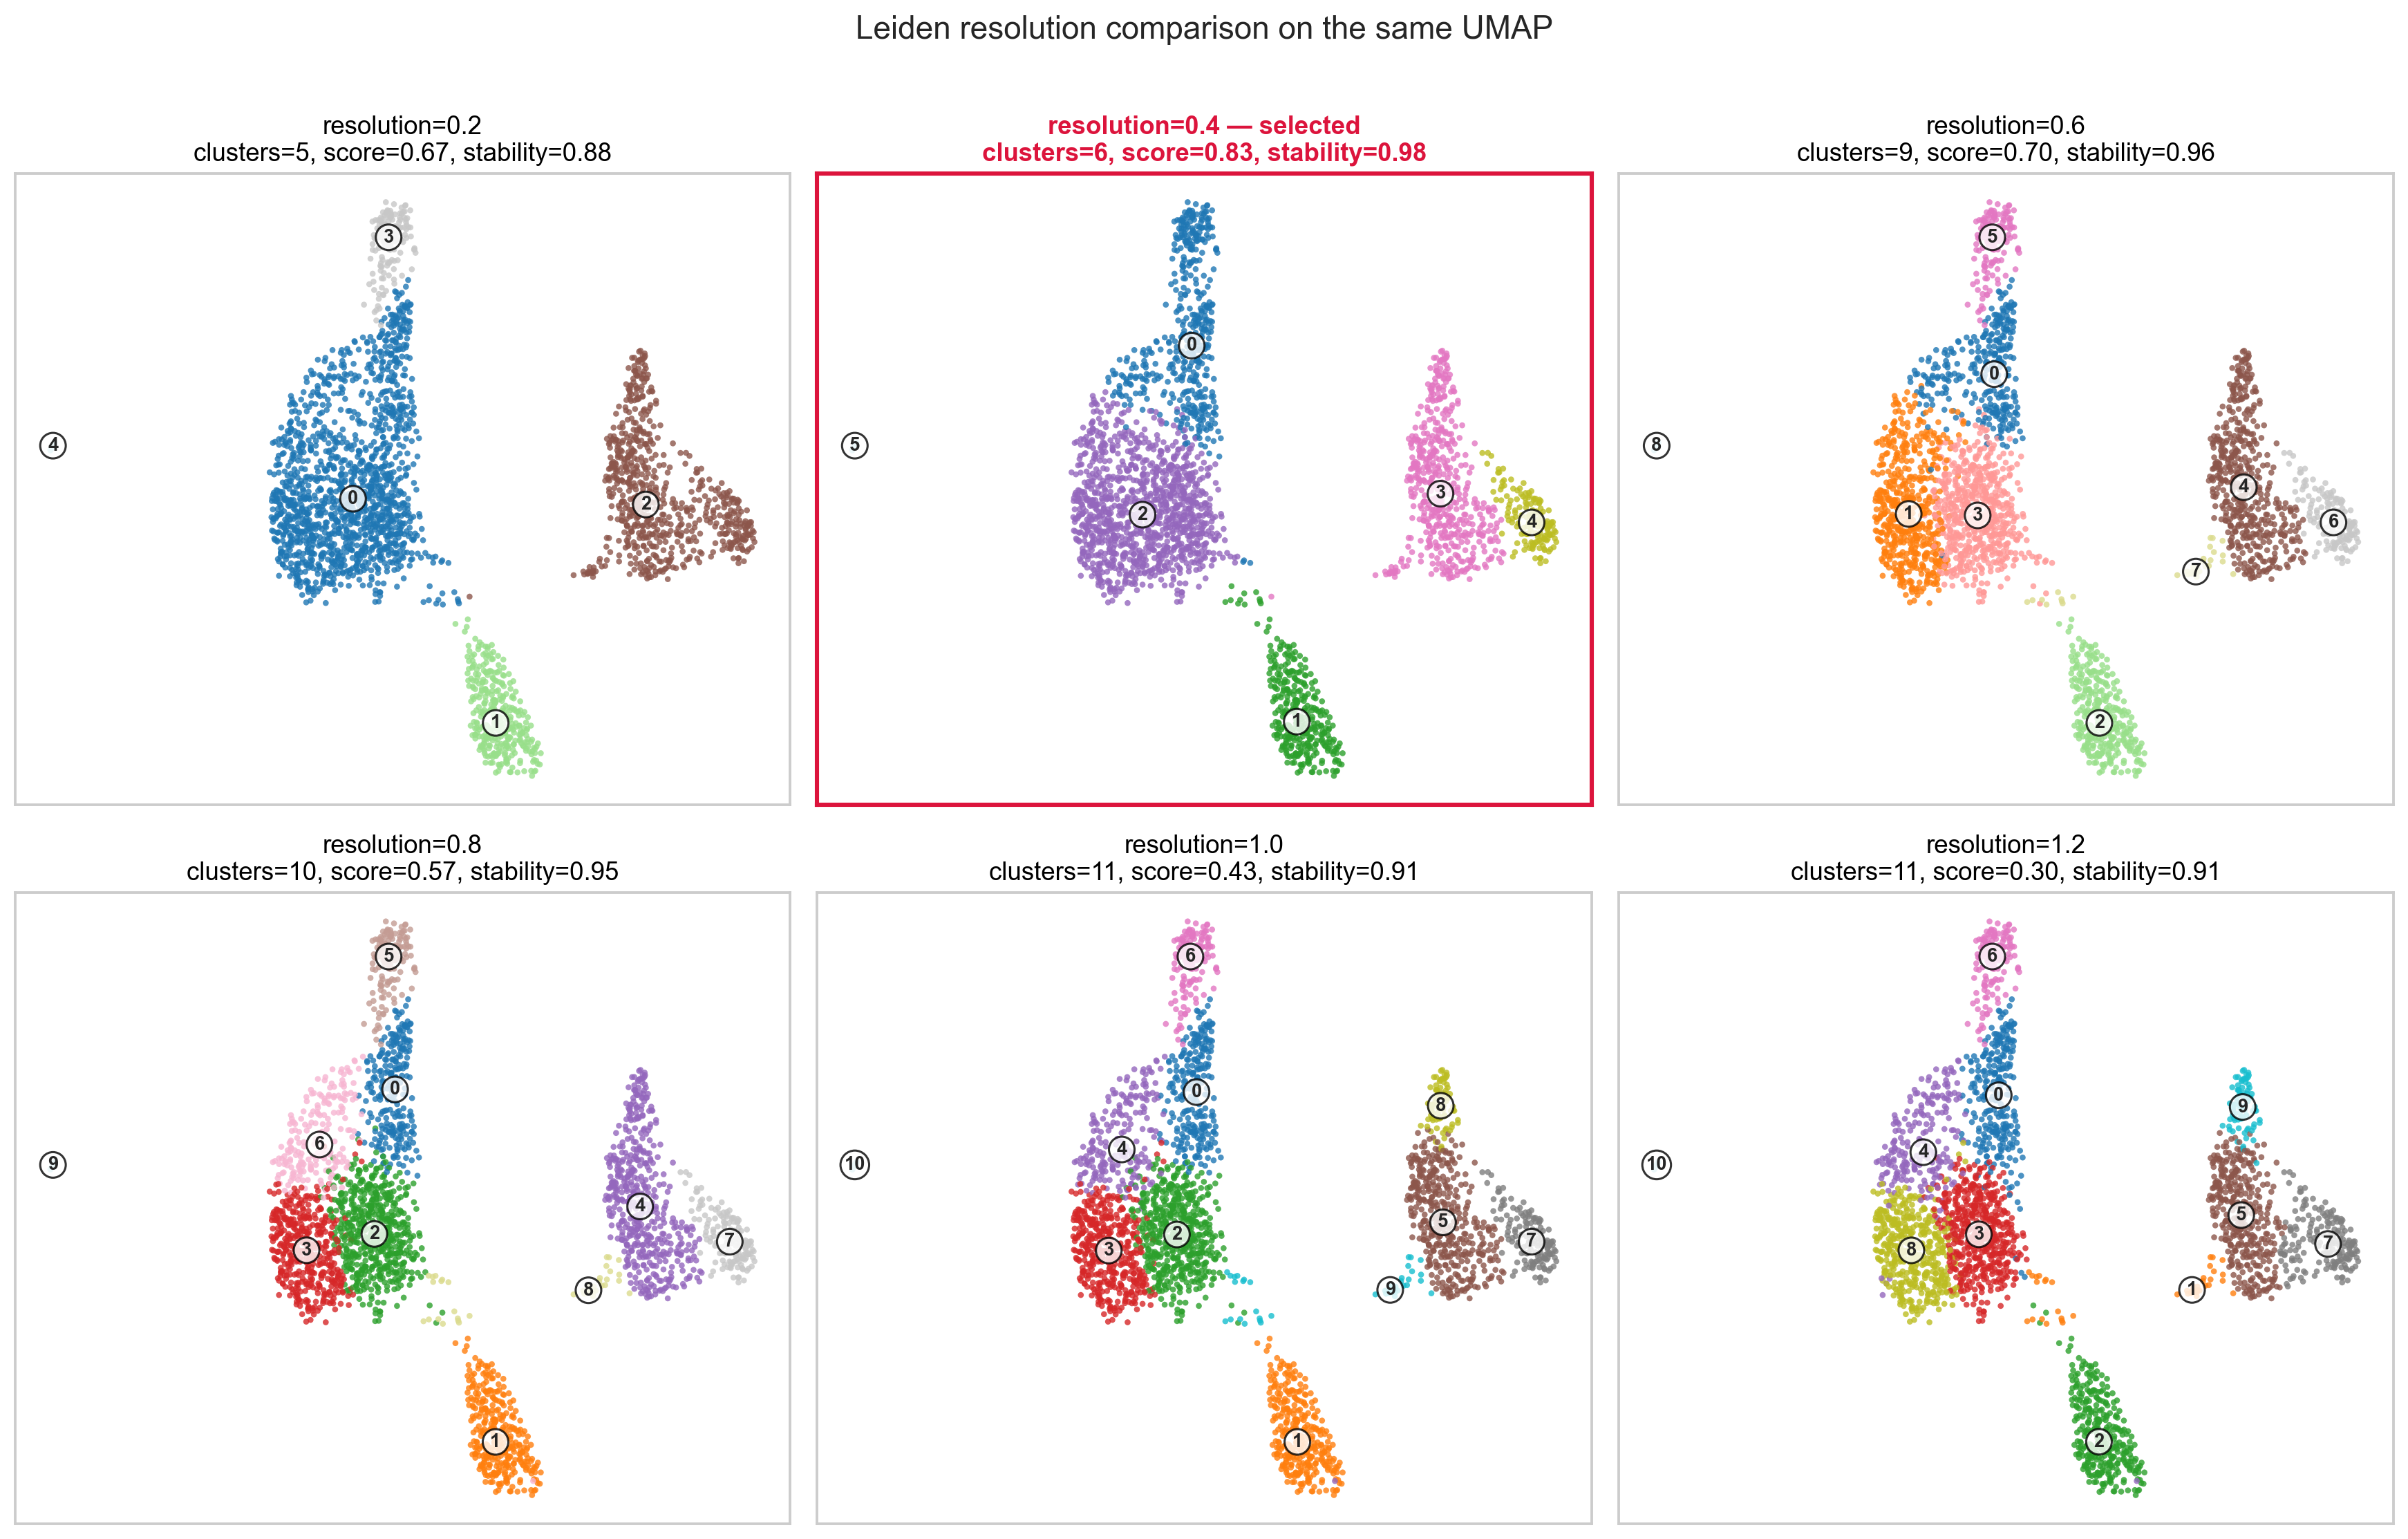

In [14]:
LEIDEN_RESOLUTIONS = (0.2, 0.4, 0.6, 0.8, 1.0, 1.2)
leiden_rows = []
leiden_labels = {}

for resolution in LEIDEN_RESOLUTIONS:
    key = f"leiden_{resolution:.1f}".replace(".", "_")
    sc.tl.leiden(
        adata,
        resolution=resolution,
        key_added=key,
        random_state=RANDOM_STATE,
        flavor="igraph",
        n_iterations=2,
        directed=False,
    )
    labels = adata.obs[key].cat.codes.to_numpy()
    leiden_labels[resolution] = labels.copy()
    n_clusters = int(np.unique(labels).size)
    sample_size = min(SILHOUETTE_SAMPLE_SIZE, adata.n_obs)
    score = (
        silhouette_score(
            X_cluster,
            labels,
            sample_size=sample_size if sample_size < adata.n_obs else None,
            random_state=RANDOM_STATE,
        )
        if n_clusters > 1 else np.nan
    )

    repeat_aris = []
    for seed in STABILITY_SEEDS:
        repeat_key = f"_leiden_repeat_{seed}"
        sc.tl.leiden(
            adata,
            resolution=resolution,
            key_added=repeat_key,
            random_state=seed,
            flavor="igraph",
            n_iterations=2,
            directed=False,
        )
        repeated = adata.obs[repeat_key].cat.codes.to_numpy()
        repeat_aris.append(adjusted_rand_score(labels, repeated))
        del adata.obs[repeat_key]

    counts = np.bincount(labels)
    qc_effects = [eta_squared(adata.obs[metric], labels) for metric in selection_qc_columns]
    leiden_rows.append({
        "resolution": resolution,
        "clusters": n_clusters,
        "silhouette": score,
        "stability_ari": np.mean(repeat_aris),
        "smallest_cluster_cells": counts.min(),
        "smallest_cluster_percent": 100 * counts.min() / adata.n_obs,
        "max_qc_eta_squared": max(qc_effects, default=0.0),
    })

leiden_diagnostics = pd.DataFrame(leiden_rows).set_index("resolution")
leiden_diagnostics["viable_size"] = (
    (leiden_diagnostics["smallest_cluster_cells"] >= MIN_ACCEPTABLE_CLUSTER_CELLS)
    & (leiden_diagnostics["smallest_cluster_percent"] >= MIN_ACCEPTABLE_CLUSTER_PERCENT)
)
leiden_diagnostics["silhouette_rank"] = leiden_diagnostics["silhouette"].rank(pct=True).fillna(0)
leiden_diagnostics["stability_rank"] = leiden_diagnostics["stability_ari"].rank(pct=True).fillna(0)
leiden_diagnostics["size_rank"] = leiden_diagnostics["smallest_cluster_percent"].rank(pct=True)
leiden_diagnostics["qc_independence_rank"] = (-leiden_diagnostics["max_qc_eta_squared"]).rank(pct=True)
leiden_diagnostics["overall_score"] = (
    0.35 * leiden_diagnostics["silhouette_rank"]
    + 0.30 * leiden_diagnostics["stability_rank"]
    + 0.20 * leiden_diagnostics["size_rank"]
    + 0.15 * leiden_diagnostics["qc_independence_rank"]
)
eligible_leiden = leiden_diagnostics["overall_score"].where(leiden_diagnostics["viable_size"])
if eligible_leiden.notna().any():
    best_leiden_resolution = float(eligible_leiden.idxmax())
else:
    best_leiden_resolution = float(leiden_diagnostics["overall_score"].idxmax())
    print("Warning: no Leiden candidate passed the minimum cluster-size rule.")

display(leiden_diagnostics.style.format({
    "silhouette": "{:.3f}", "stability_ari": "{:.3f}",
    "smallest_cluster_percent": "{:.1f}%", "max_qc_eta_squared": "{:.3f}",
    "overall_score": "{:.3f}",
}))

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
for axis, resolution in zip(axes.flat, LEIDEN_RESOLUTIONS):
    labels = leiden_labels[resolution]
    axis.scatter(
        umap[:, 0], umap[:, 1], c=labels, cmap="tab20",
        s=8, alpha=0.8, linewidths=0,
    )
    for cluster in np.unique(labels):
        center = np.median(umap[labels == cluster], axis=0)
        axis.text(
            center[0], center[1], str(cluster), ha="center", va="center",
            fontsize=9, fontweight="bold",
            bbox={"boxstyle": "circle,pad=0.2", "facecolor": "white", "alpha": 0.8, "edgecolor": "black"},
        )
    is_selected = np.isclose(resolution, best_leiden_resolution)
    axis.set_title(
        f"resolution={resolution:.1f}{' — selected' if is_selected else ''}\n"
        f"clusters={leiden_diagnostics.loc[resolution, 'clusters']}, "
        f"score={leiden_diagnostics.loc[resolution, 'overall_score']:.2f}, "
        f"stability={leiden_diagnostics.loc[resolution, 'stability_ari']:.2f}",
        color="crimson" if is_selected else "black",
        fontweight="bold" if is_selected else "normal",
    )
    axis.set(xticks=[], yticks=[])
    if is_selected:
        for spine in axis.spines.values():
            spine.set_visible(True)
            spine.set_color("crimson")
            spine.set_linewidth(2)
plt.suptitle("Leiden resolution comparison on the same UMAP", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### Selected Leiden solution and comparison with K-means

Adjusted Rand index (ARI) quantifies agreement between the selected Leiden and K-means partitions. An ARI near 1 means they recover nearly identical groups; an ARI near 0 means their agreement is no better than chance. Disagreement is not automatically a failure: Leiden can capture irregular graph communities that K-means cannot, while K-means can provide a simpler broad partition. Prefer the solution whose clusters have stable boundaries, viable sizes, coherent marker programs, and limited QC confounding.

,method,selected_parameter,clusters,smallest_cluster_cells
0,K-means,K=2,2,685
1,Leiden,resolution=0.4,6,11


Agreement between selected K-means and Leiden partitions: ARI=0.387


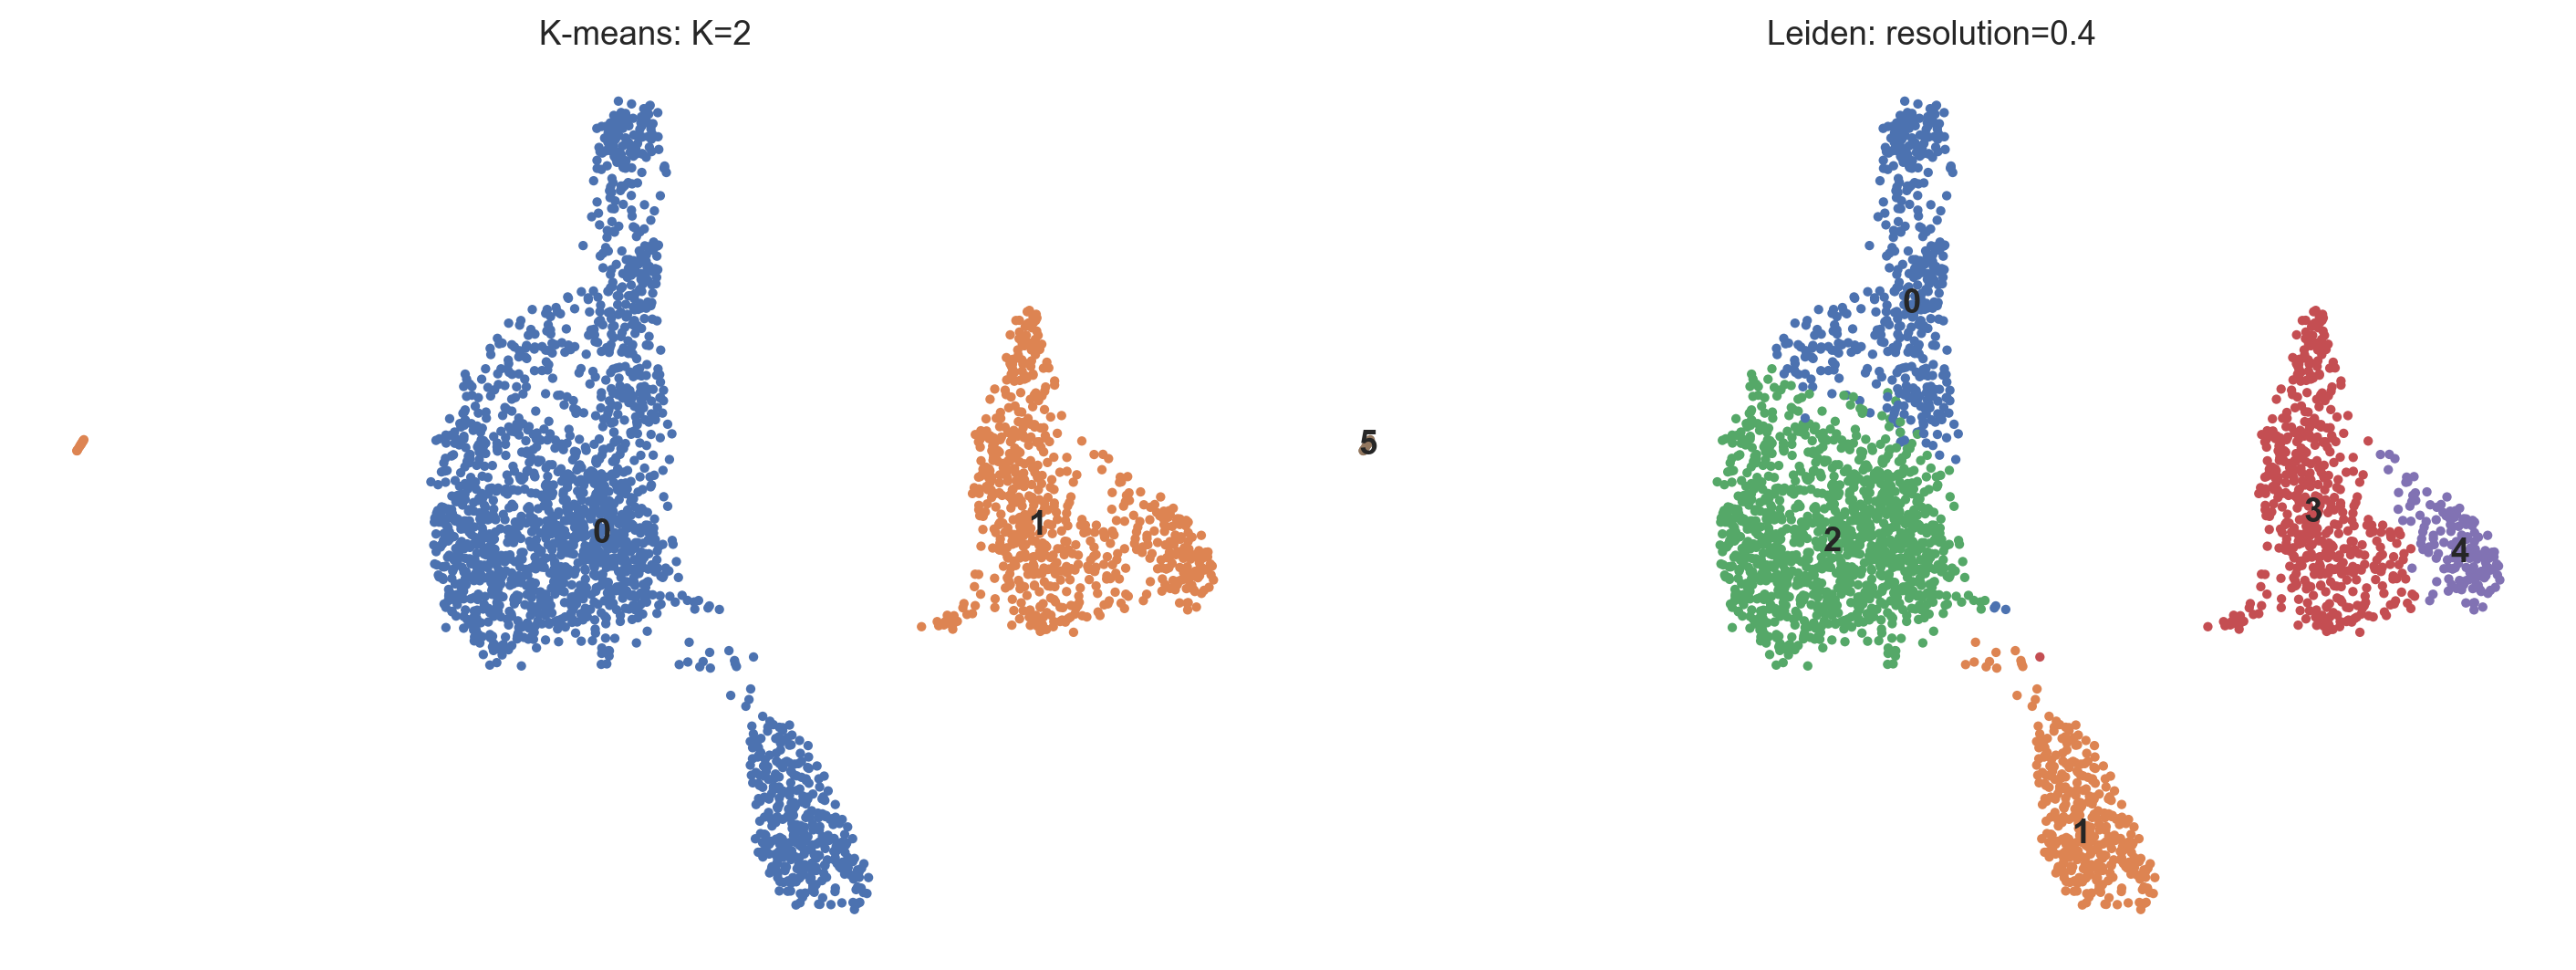

Updated pbmc3k_phase2_clustered.h5ad with selected Leiden labels and diagnostics.


In [15]:
selected_leiden_key = f"leiden_{best_leiden_resolution:.1f}".replace(".", "_")
adata.obs["leiden"] = adata.obs[selected_leiden_key].copy()
leiden_kmeans_ari = adjusted_rand_score(
    adata.obs["kmeans"].cat.codes,
    adata.obs["leiden"].cat.codes,
)

comparison = pd.DataFrame({
    "method": ["K-means", "Leiden"],
    "selected_parameter": [f"K={best_k}", f"resolution={best_leiden_resolution:.1f}"],
    "clusters": [adata.obs["kmeans"].nunique(), adata.obs["leiden"].nunique()],
    "smallest_cluster_cells": [
        adata.obs["kmeans"].value_counts().min(),
        adata.obs["leiden"].value_counts().min(),
    ],
})
display(comparison)
print(f"Agreement between selected K-means and Leiden partitions: ARI={leiden_kmeans_ari:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc.pl.umap(adata, color="kmeans", legend_loc="on data", title=f"K-means: K={best_k}", ax=axes[0], show=False)
sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
    title=f"Leiden: resolution={best_leiden_resolution:.1f}",
    ax=axes[1],
    show=False,
)
plt.tight_layout()
plt.show()

adata.uns["leiden_model_selection"] = {
    "resolutions": leiden_diagnostics.index.to_numpy(),
    "cluster_counts": leiden_diagnostics["clusters"].to_numpy(),
    "silhouette": leiden_diagnostics["silhouette"].to_numpy(),
    "stability_ari": leiden_diagnostics["stability_ari"].to_numpy(),
    "overall_score": leiden_diagnostics["overall_score"].to_numpy(),
    "selected_resolution": best_leiden_resolution,
    "kmeans_agreement_ari": leiden_kmeans_ari,
    "selection_rule": "best viable multi-evidence score: 35% silhouette, 30% stability, 20% minimum cluster size, 15% QC independence",
}
adata.write_h5ad(OUTPUT, compression="gzip")
print(f"Updated {OUTPUT.name} with selected Leiden labels and diagnostics.")